In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from get_train_test import TrainTestBuilder

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc, f1_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.calibration import calibration_curve

In [2]:

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    mce = 0

    for i in range(n_bins):
        start, end = bins[i], bins[i+1]
        idx = (y_prob >= start) & (y_prob < end)

        if np.sum(idx) == 0:
            continue

        prob_avg = y_prob[idx].mean()
        true_avg = y_true[idx].mean()

        gap = abs(prob_avg - true_avg)
        weight = np.sum(idx) / len(y_prob)

        ece += weight * gap
        mce = max(mce, gap)

    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

    plt.figure(figsize=(7, 6))
    plt.plot(prob_pred, prob_true, marker='o', label='Model Calibration')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')

    plt.title(f'Calibration Curve\nECE={ece:.3f}  MCE={mce:.3f}')
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")
    plt.legend()
    plt.grid(True)
    plt.show()

def save_results(df_model, probs_2d, train_len, split, fp, odds_feats):
    """
    Save model predictions with odds and outcomes.

    Parameters
    ----------
    df_model : pd.DataFrame
        Full dataframe before splitting.
    nn_probs_2d : np.ndarray
        N x 2 predicted probabilities (blue, red).
    train_len : int
        Number of rows in training split.
    split : str
        'train' or 'test'.
    fp : str
        Output filepath for CSV.
    odds_feats : list
        List of odds-related column names.
    """
    df = df_model.copy()

    # ---- Slice dataframe correctly ----
    if split == "train":
        df_slice = df.iloc[:train_len].reset_index(drop=True)
    elif split == "test":
        df_slice = df.iloc[train_len:].reset_index(drop=True)
    else:
        raise ValueError("split must be 'train' or 'test'")

    # ---- Safety check ----
    if len(df_slice) != probs_2d.shape[0]:
        raise ValueError(f"Shape mismatch: df_slice={len(df_slice)} vs probs={probs_2d.shape[0]}")
    df_slice['red_probs'] = probs_2d[:,1]
    df_slice['blue_probs'] = probs_2d[:,0]
    df_slice['pred_winner'] = np.where(df_slice['red_probs'] > df_slice['blue_probs'],1,0)
    
    df_slice["correct_pred"] = (df_slice["pred_winner"] == df_slice['winner']).astype(int)

    # ---- Additional calculated columns ----
    df_slice["prob_winner"] = df_slice[["red_probs", "blue_probs"]].max(axis=1)
    df_slice["winner_odds"] = np.where(df_slice["winner"] == 1, df_slice['open_red'], df_slice['open_blue'])
    df_slice["choice_fighter_bet"] = np.where(df_slice["pred_winner"] == 1, df_slice['open_red'], df_slice['open_blue'])
    df_slice["Date"] = pd.to_datetime(df_slice['event_date'], errors='coerce')

    # ---- Save CSV ----
    df_slice.to_csv(fp, index=False)
    return df_slice

def calc_net_odds(df_test_results, odds_type):
    # Choose the probabilities and decimal odds according to prediction
    df_test_results['proba_choice'] = np.where(df_test_results['pred_winner']==1,
                                               df_test_results['proba_red'], 
                                               df_test_results['proba_blue'])
    df_test_results['dec_choice'] = np.where(df_test_results['pred_winner']==1,
                                             df_test_results[f'dec_{odds_type}_red'],
                                             df_test_results[f'dec_{odds_type}_blue'])
    # EV
    df_test_results['ev'] = df_test_results['proba_choice'] * (df_test_results['dec_choice']-1) - (1-df_test_results['proba_choice'])
    
    # Keep only positive EV bets
    df_ev = df_test_results[df_test_results['ev'] > 0].copy()

    print(df_ev.shape, df_test_results.shape)
    
    # Calculate adjusted profit per bet
    df_ev['adj_profit'] = np.where(df_ev['pred_winner'] == df_ev['winner'],
                                   df_ev['dec_choice']-1, -1)
    
    # Separate fav vs dog
    df_ev['is_fav'] = np.where(
        ((df_ev['pred_winner']==1) & (df_ev[f'{odds_type}_red'] <= df_ev[f'{odds_type}_blue'])) |
        ((df_ev['pred_winner']==0) & (df_ev[f'{odds_type}_blue'] < df_ev[f'{odds_type}_red'])),
        1, 0
    )
    
    fav_sum = df_ev.loc[df_ev['is_fav']==1, 'adj_profit'].tolist()
    dog_sum = df_ev.loc[df_ev['is_fav']==0, 'adj_profit'].tolist()
    
    # Compute stats
    def summarize(profits):
        n_total = len(profits)
        n_correct = sum(1 for x in profits if x != -1)
        n_incorrect = n_total - n_correct
        pct_correct = n_correct/n_total*100 if n_total>0 else 0
        return n_total, n_correct, n_incorrect, pct_correct

    fav_stats = summarize(fav_sum)
    dog_stats = summarize(dog_sum)
    
    print("Sum of decimal odds for favorite predictions (adjusted):", sum(fav_sum))
    print("Sum of decimal odds for underdog predictions (adjusted):", sum(dog_sum))
    print(f"Fav bets: {fav_stats[0]} total, {fav_stats[1]} correct, {fav_stats[2]} incorrect, {fav_stats[3]:.2f}% correct")
    print(f"Dog bets: {dog_stats[0]} total, {dog_stats[1]} correct, {dog_stats[2]} incorrect, {dog_stats[3]:.2f}% correct")

def plot_juice_histogram(df_, odds_type):
    df = df_.copy()

    # Determine if the predicted winner is favorite
    df['is_fav'] = np.where(
        ((df['pred_winner']==1) & (df[f'{odds_type}_red'] <= df[f'{odds_type}_blue'])) |
        ((df['pred_winner']==0) & (df[f'{odds_type}_blue'] < df[f'{odds_type}_red'])),
        1, 0
    )

    # Get juice of the chosen fighter
    df['choice_juice'] = np.where(
        df['pred_winner'] == 1,
        df[f'juice_{odds_type}_red'],
        df[f'juice_{odds_type}_blue']
    )

    juice_fav = df.loc[df['is_fav']==1, 'choice_juice']
    juice_dog = df.loc[df['is_fav']==0, 'choice_juice']

    # Compute stats
    fav_mean, fav_std = juice_fav.mean(), juice_fav.std()
    dog_mean, dog_std = juice_dog.mean(), juice_dog.std()

    # Plot histograms with KDE
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    sns.histplot(juice_fav, bins=60, kde=True, color='blue', alpha=0.6, ax=axes[0])
    axes[0].set_title(f'Favorite {odds_type} Juice\nMean={fav_mean:.2f}, Std={fav_std:.2f}')
    axes[0].set_xlabel('Juice')
    axes[0].set_ylabel('Count')
    sns.despine(ax=axes[0])

    sns.histplot(juice_dog, bins=60, kde=True, color='red', alpha=0.6, ax=axes[1])
    axes[1].set_title(f'Underdog {odds_type} Juice\nMean={dog_mean:.2f}, Std={dog_std:.2f}')
    axes[1].set_xlabel('Juice')
    sns.despine(ax=axes[1])

    plt.tight_layout()
    plt.show()

def plot_line_movement(df_, odds_type):
    df = df_.copy()

    # Determine if the predicted winner is favorite
    df['is_fav'] = np.where(
        ((df['pred_winner']==1) & (df[f'{odds_type}_red'] <= df[f'{odds_type}_blue'])) |
        ((df['pred_winner']==0) & (df[f'{odds_type}_blue'] < df[f'{odds_type}_red'])),
        1, 0
    )

    # Get juice of the chosen fighter
    df['choice_close_line'] = np.where(
        df['pred_winner'] == 1,
        df[f'{odds_type}_red'],
        df[f'{odds_type}_blue']
    )

    df['choice_open_line'] = np.where(
        df['pred_winner'] == 1,
        df[f'open_red'],
        df[f'open_blue']
    )

    df['choice_line_movement'] = df['choice_close_line'] - df['choice_open_line'] 
    # Compute stats
    mean, std = df['choice_line_movement'].mean(), df['choice_line_movement'].std()

    # Plot histograms with KDE

    sns.histplot( df['choice_line_movement'].values, bins=60, kde=True, color='blue', alpha=0.6)
    plt.title(f'Line Movement {odds_type} \nMean={mean:.2f}, Std={std:.2f}')
    plt.xlabel('Line Movement')
    plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

def analyze_line_movement_perf(df, odds_type='close', filter_ev=True):
    df = df.copy()

    # -----------------------------
    # 0. Extract probability of chosen side
    # -----------------------------
    df['proba_choice'] = np.where(
        df['pred_winner'] == 1,
        df['proba_red'],
        df['proba_blue']
    )

    # -----------------------------
    # 1. Compute decimal odds
    # -----------------------------
    def american_to_decimal(x):
        if x < 0:
            return 100 / abs(x) + 1
        else:
            return x / 100 + 1

    df['red_decimal']  = df[f'{odds_type}_red'].apply(american_to_decimal)
    df['blue_decimal'] = df[f'{odds_type}_blue'].apply(american_to_decimal)

    df['choice_decimal_odds'] = np.where(
        df['pred_winner'] == 1,
        df['red_decimal'],
        df['blue_decimal']
    )

    # Convert to NET odds
    df['choice_net_odds'] = df['choice_decimal_odds'] - 1.0

    # -----------------------------
    # 2. Expected Value (EV)
    # -----------------------------
    df['EV'] = df['proba_choice'] * df['choice_net_odds'] - (1 - df['proba_choice'])

    # Filter only EV > 0 bets?
    if filter_ev:
        df = df[df['EV'] > 0].reset_index(drop=True)

    # -----------------------------
    # 3. Determine fav/dog at open & close
    # -----------------------------
    df['fav_open'] = np.where(df['open_red'] <= df['open_blue'], 1, 0)
    df['fav_close'] = np.where(df[f'{odds_type}_red'] <= df[f'{odds_type}_blue'], 1, 0)

    df['choice_open_fav'] = np.where(
        ((df['pred_winner']==1) & (df['fav_open']==1)) |
        ((df['pred_winner']==0) & (df['fav_open']==0)),
        1, 0
    )

    df['choice_close_fav'] = np.where(
        ((df['pred_winner']==1) & (df['fav_close']==1)) |
        ((df['pred_winner']==0) & (df['fav_close']==0)),
        1, 0
    )

    # -----------------------------
    # 4. Movement category
    # -----------------------------
    def movement_label(row):
        if row['choice_open_fav']==1 and row['choice_close_fav']==0:
            return "Fav → Dog"
        if row['choice_open_fav']==0 and row['choice_close_fav']==1:
            return "Dog → Fav"
        if row['choice_open_fav']==1 and row['choice_close_fav']==1:
            return "Stayed Fav"
        return "Stayed Dog"

    df['movement_category'] = df.apply(movement_label, axis=1)

    # -----------------------------
    # 5. Profit
    # -----------------------------
    df['correct'] = (df['pred_winner'] == df['winner']).astype(int)
    df['profit'] = np.where(df['correct'] == 1, df['choice_net_odds'], -1)

    # -----------------------------
    # 6. Stats by movement category
    # -----------------------------
    stats = df.groupby('movement_category').agg(
        accuracy=('correct', 'mean'),
        n=('correct', 'count'),
        total_profit=('profit', 'sum'),
        mean_EV=('EV', 'mean')
    ).reset_index()

    # -----------------------------
    # 7. PLOTS
    # -----------------------------
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Accuracy plot
    sns.barplot(data=stats, x='movement_category', y='accuracy', ax=axs[0])
    axs[0].set_title(f"Accuracy by Line Movement Category\nEV filter = {filter_ev}")
    axs[0].set_xlabel("Category")
    axs[0].set_ylabel("Accuracy")
    axs[0].set_ylim(0, 1)

    # Profit plot
    sns.barplot(data=stats, x='movement_category', y='total_profit', ax=axs[1])
    axs[1].set_title("Total Net Profit by Category")
    axs[1].set_xlabel("Category")
    axs[1].set_ylabel("Total Net Profit")

    plt.tight_layout()
    plt.show()

    return stats


def plot_accuracy_by_variable(df, variable, pred_col="correct_pred"):
    grouped = df.groupby(variable)[pred_col].agg(["mean", "count"])

    plt.figure(figsize=(10, 6))
    bars = plt.bar(grouped.index, grouped["mean"], color="skyblue")

    plt.title(f"Prediction Accuracy by {variable}")
    plt.ylabel("Accuracy")
    plt.xlabel(variable)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")

    # Annotate with counts AND accuracy %
    for bar, (acc, count) in zip(bars, zip(grouped["mean"], grouped["count"])):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"n={count}\n{acc*100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

def plot_accuracy_by_bins(df_, variable, bins=10, pred_col="correct_pred"):
    df = df_.copy()
    # Create bins using pandas.cut
    df["_bins"] = pd.cut(df[variable], bins=bins)

    # Group by bins
    grouped = df.groupby("_bins")[pred_col].agg(["mean", "count"])

    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(grouped.index.astype(str), grouped["mean"], color="skyblue")

    plt.title(f"Prediction Accuracy by Binned {variable}")
    plt.ylabel("Accuracy")
    plt.xlabel(variable)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")

    # Annotate counts + accuracy %
    for bar, (acc, count) in zip(bars, zip(grouped["mean"], grouped["count"])):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"n={count}\n{acc*100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

    # Clean temporary column
    df.drop(columns=["_bins"], inplace=True)

def plot_model_metrics(y_test, y_pred, probs):
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # ROC
    fpr, tpr, thresholds_roc = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    # F1 vs threshold
    thresholds = np.linspace(0, 1, 200)
    f1_scores = [f1_score(y_test, (probs >= t).astype(int)) for t in thresholds]

    # ------------------------------
    # Create side-by-side figure
    # ------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    # ---- 1. Confusion Matrix ----
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    # Plot on our subplot axis, not a new figure
    disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
    axes[0].set_title("Confusion Matrix - Logistic Regression")

    # Explicit axis labels
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(["Blue Fighter (0)", "Red Fighter (1)"])
    axes[0].set_yticklabels(["Blue Fighter (0)", "Red Fighter (1)"])

    # ---- 2. ROC Curve ----
    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].grid(True)
    axes[1].legend()

    # ---- 3. F1 vs Threshold ----
    axes[2].plot(thresholds, f1_scores)
    axes[2].set_xlabel("Threshold")
    axes[2].set_ylabel("F1 Score")
    axes[2].set_title("F1 Score vs Threshold")
    axes[2].grid(True)

    # ---- 4. Accuracy + Brier ----
    # axes[3].axis("off")
    # text = (
    #     f"Model Performance\n\n"
    #     f"Accuracy: {accuracy:.4f}\n"
    #     f"Brier Score: {brier:.4f}"
    # )
    # axes[3].text(0.1, 0.5, text, fontsize=14, verticalalignment="center")

    plt.tight_layout()
    plt.show()

def save_results(df_model, probs_2d, fp):
    """
    df_model : full dataframe BEFORE splitting
    probs_2d : blue model probs, red model probs
    fp : output filepath
    """
    df = df_model.copy()
    df[['proba_blue', 'proba_red']] = probs_2d

    df["pred_winner"] = np.argmax(probs_2d, axis=1)
    df["correct_pred"] = (df["pred_winner"] == df["winner"]).astype(int)
    df["prob_winner"] = df[["proba_blue", "proba_red"]].max(axis=1)

    df['Date'] = df['event_date']
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    df.to_csv(fp, index=False)
    return df

def print_gender_accuracy(df, weight_col='weight_class', pred_col='pred_winner', true_col='winner'):
    """
    Prints the accuracy of predictions separately for men and women weight classes.

    Parameters:
    - df: pd.DataFrame containing the columns for weight class, predicted winner, and true winner
    - weight_col: name of the column with weight class strings
    - pred_col: name of the column with predicted winner
    - true_col: name of the column with true winner
    """
    
    # Identify Men / Women
    df = df.copy()
    df['gender_group'] = df[weight_col].apply(lambda x: 'Women' if 'Women' in str(x) else 'Men')

    # Compute accuracy for men
    men_df = df[df['gender_group'] == 'Men']
    men_acc = accuracy_score(men_df[true_col], men_df[pred_col])

    # Compute accuracy for women
    women_df = df[df['gender_group'] == 'Women']
    women_acc = accuracy_score(women_df[true_col], women_df[pred_col])

    print(f"Accuracy for Men weight classes:   {men_acc:.3f}")
    print(f"Accuracy for Women weight classes: {women_acc:.3f}")


def InverseProbabilityNC(predicted_score, y):
    """
    Computes nonconformity scores based on inverse probability.
    """
    prob = np.zeros(y.size, dtype=np.float32)
    for i, y_ in enumerate(y):
        if y_ >= predicted_score.shape[1]:
            prob[i] = 0
        else:
            prob[i] = predicted_score[i, int(y_)]
    return 1 - prob


def compute_tcp_pvalues(X_train, y_train, X_test, n_classes=2):
    """
    Computes Transductive Conformal Prediction p-values for a test set.

    Returns:
        p_values_tcp : np.ndarray of shape (n_test, n_classes)
    """
    # ------------------------------
    # Base training model
    # ------------------------------
    base_model = sm.Logit(y_train, X_train).fit(disp=False)

    p_train = base_model.predict(X_train)
    pred_train = np.column_stack([1 - p_train, p_train])

    # training nonconformity
    nc_train = InverseProbabilityNC(pred_train, y_train.values)

    # ------------------------------
    # Transductive Conformal Prediction
    # ------------------------------
    n_test = len(X_test)
    p_values_tcp = np.zeros((n_test, n_classes))

    for i in range(n_test):

        x_i = X_test.iloc[[i]]  # shape (1,d)

        for c in range(n_classes):

            # Augmented dataset (train + test point)
            X_aug = sm.add_constant(np.vstack([X_train, x_i]))
            y_aug = np.concatenate([y_train.values, np.array([c])])

            # Fit new model
            model_aug = sm.Logit(y_aug, X_aug).fit(disp=False)

            # Predicted probabilities for augmented dataset
            p_aug = model_aug.predict(X_aug)
            pred_aug = np.column_stack([1 - p_aug, p_aug])

            # Compute nonconformity scores
            nc_aug = InverseProbabilityNC(pred_aug, y_aug)

            # TCP p-value for test point
            test_nc = nc_aug[-1]
            calib_nc = nc_aug[:-1]
            p_values_tcp[i, c] = (np.sum(calib_nc >= test_nc) + 1) / (len(calib_nc) + 1)

    return p_values_tcp


def poisson_binomial_pmf(probs, k):
    """
    probs : list or array of success probabilities p_i
    k     : number of total successes in the sum
    """
    # Start distribution at P(X=0) = 1
    pmf = np.array([1.0])
    
    # Convolution process
    for p in probs:
        pmf = np.convolve(pmf, [1-p, p])
    
    return pmf[k]



def conformal_analysis(
    df_test_results,
    y_pred, 
    y_test, 
    p_values_tcp, 
    results,
    open_odds=True
):
    
    # ---- Build dataframe ----
    if open_odds is not True: 
        test_choice_odds1 = np.where(df_test_results['pred_winner']==1, 
                                    df_test_results['dec_close1_red']-1, 
                                    df_test_results['dec_close1_blue']-1)

        test_choice_odds2 = np.where(df_test_results['pred_winner']==1, 
                                    df_test_results['dec_close2_red']-1, 
                                    df_test_results['dec_close2_blue']-1)

        df_tcp = pd.DataFrame({
            "y_pred": y_pred,
            'y_true': y_test,
            'choice_netodds_close1': test_choice_odds1, 
            'choice_netodds_close2': test_choice_odds2, 
            "p_red":  p_values_tcp[:, 1],
            "p_blue": p_values_tcp[:, 0],
            'p_red_model': results['test_pred_proba'],
            'p_blue_model': 1-results['test_pred_proba']
        })
    
    else: 
        test_open_odds = np.where(df_test_results['pred_winner']==1, 
                            df_test_results['dec_open_red']-1, 
                            df_test_results['dec_open_blue']-1)
        
        print(test_open_odds.shape, y_pred.shape, y_test.shape, p_values_tcp.shape, results['test_pred_proba'].shape)

        df_tcp = pd.DataFrame({
            "y_pred": y_pred,
            'y_true': y_test,
            'test_open_odds': test_open_odds, 
            "p_red":  p_values_tcp[:, 1],
            "p_blue": p_values_tcp[:, 0],
            'p_red_model': results['test_pred_proba'],
            'p_blue_model': 1-results['test_pred_proba']
        })
        print(df_tcp.shape)


    # conformal predicted label
    df_tcp["pred_conf"] = df_tcp[["p_red", "p_blue"]].idxmax(axis=1).map({"p_red":1, "p_blue":0})

    # confidence score
    df_tcp["confidence"] = df_tcp[["p_red","p_blue"]].max(axis=1)

    # uncertainty score
    df_tcp["uncertainty"] = df_tcp[["p_red","p_blue"]].min(axis=1)

    # agreement check
    df_tcp["agreement"] = (df_tcp["y_pred"] == df_tcp["pred_conf"]).astype(int)

    # prediction set size
    alpha = 0.1
    df_tcp["set_size"] = (df_tcp["p_red"] >= alpha).astype(int) + \
                         (df_tcp["p_blue"] >= alpha).astype(int)

    # margin
    df_tcp["gap"] = np.abs(df_tcp["p_red"] - df_tcp["p_blue"])

    # ---- PLOTTING ----
    fig, axes = plt.subplots(3, 2, figsize=(12, 14))
    axes = axes.flatten()

    # hist p_red + p_blue
    axes[0].hist(df_tcp["p_red"], bins=40, alpha=0.6, label="p_red")
    axes[0].hist(df_tcp["p_blue"], bins=40, alpha=0.6, label="p_blue")
    axes[0].legend()
    axes[0].set_title("p-value distributions")

    # scatter p_red vs p_blue
    axes[1].scatter(df_tcp["p_red"], df_tcp["p_blue"], alpha=0.5)
    axes[1].set_xlabel("p_red")
    axes[1].set_ylabel("p_blue")
    axes[1].set_title("Joint p-value scatter")

    # set size histogram
    axes[2].hist(df_tcp["set_size"], bins=[0, 1, 2, 3], align="left", rwidth=0.8)
    axes[2].set_title("Conformal set size distribution")
    axes[2].set_xticks([0, 1, 2])

    # confidence by predicted class
    sns.boxplot(x="y_pred", y="confidence", data=df_tcp, ax=axes[3])
    axes[3].set_title("Confidence by predicted class")

    # margin histogram
    axes[4].hist(df_tcp["gap"], bins=40)
    axes[4].set_title("Conformal margin distribution")

    # agreement score text
    agreement_rate = df_tcp["agreement"].mean()
    axes[5].text(0.1, 0.5, f"Agreement rate = {agreement_rate:.3f}", fontsize=14)
    axes[5].axis("off")

    plt.tight_layout()
    plt.show()

    return df_tcp





In [3]:

def build_gmm_feats(df_model):
    blue_feats = ['td_defense_pct_blue','td_accuracy_pct_blue', 'control_pm_blue',
    'sig_str_defense_pct_blue', 'sig_str_accuracy_pct_blue', 'sig_str_landed_pm_blue','sig_str_absorbed_pm_blue',
    'kd_pm_blue', 'total_fight_time_blue', 'age_blue', 'reach_blue', 'total_bonus_blue', 'elo_blue',
    'win_pct_blue', 'ko_losses_blue']

    red_feats = ['td_defense_pct_red', 'td_accuracy_pct_red', 'control_pm_red',
    'sig_str_defense_pct_red', 'sig_str_accuracy_pct_red', 'sig_str_landed_pm_red', 'sig_str_absorbed_pm_red',
    'kd_pm_red',
    'total_fight_time_red', 'age_red', 'reach_red', 'total_bonus_red', 
    'elo_red', 'win_pct_red', 'ko_losses_red']

    df_mens = df_model[df_model['womens_fight']==0]
    df_mens_red  = df_mens[red_feats].rename(columns=lambda x: x.replace("_red", ""))
    df_mens_blue = df_mens[blue_feats].rename(columns=lambda x: x.replace("_blue", ""))

    df_womens = df_model[df_model['womens_fight']==1]
    df_womens_red  = df_womens[red_feats].rename(columns=lambda x: x.replace("_red", ""))
    df_womens_blue = df_womens[blue_feats].rename(columns=lambda x: x.replace("_blue", ""))

    df_men_all = pd.concat([df_mens_red, df_mens_blue], axis=0, join="inner") # columns automatically aligned by name 
    df_women_all = pd.concat([df_womens_red, df_womens_blue], axis=0, join="inner")
    return df_men_all, df_women_all

def fit_gmm(X, n_components=4, covariance_type="full", random_state=0):
    """
    Standardizes X, fits a GMM, and computes silhouette score.
    Returns: model, labels, X_proc, silhouette
    """
    scaler = StandardScaler()
    X_proc = scaler.fit_transform(X)

    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=random_state
    )
    gmm.fit(X_proc)
    labels = gmm.predict(X_proc)

    # compute silhouette
    sil = silhouette_score(X_proc, labels)

    return gmm, scaler, X_proc, sil

def add_cluster_labels(df, gmm, scaler):
    blue_feats = ['td_defense_pct_blue','td_accuracy_pct_blue', 'control_pm_blue',
    'sig_str_defense_pct_blue', 'sig_str_accuracy_pct_blue', 'sig_str_landed_pm_blue','sig_str_absorbed_pm_blue',
    'kd_pm_blue', 'total_fight_time_blue', 'age_blue', 'reach_blue', 'total_bonus_blue', 'elo_blue',
    'win_pct_blue', 'ko_losses_blue']

    red_feats = ['td_defense_pct_red', 'td_accuracy_pct_red', 'control_pm_red',
    'sig_str_defense_pct_red', 'sig_str_accuracy_pct_red', 'sig_str_landed_pm_red', 'sig_str_absorbed_pm_red',
    'kd_pm_red',
    'total_fight_time_red', 'age_red', 'reach_red', 'total_bonus_red', 
    'elo_red', 'win_pct_red', 'ko_losses_red']

    red_labels = []
    blue_labels = []


    red_labels = gmm.predict(scaler.transform(df[red_feats].values))
    blue_labels = gmm.predict(scaler.transform(df[blue_feats].values))

    df['red_gmm_cluster'] = pd.Series(red_labels).astype('category')
    df['blue_gmm_cluster'] = pd.Series(blue_labels).astype('category')
    print(f"Added GMM clusters: {df['red_gmm_cluster'].nunique()} red clusters, "
            f"{df['blue_gmm_cluster'].nunique()} blue clusters.")

    return df

def run_logit_model(
        X_train, y_train,
        X_test, y_test, 
        cov_type="HC3",
        n_bins=20,
        vif_func=None
    ):

    # --- add constant ---
    X_train_sm = sm.add_constant(X_train.copy())
    X_test_sm = sm.add_constant(X_test.copy())

    # --- fit model ---
    model = sm.Logit(y_train, X_train_sm).fit(cov_type=cov_type, disp=False)

    # --- predictions ---
    train_pred = model.predict(X_train_sm)
    train_class = (train_pred >= 0.5).astype(int)
    test_pred = model.predict(X_test_sm)
    test_class = (test_pred >= 0.5).astype(int)

    # --- metrics ---
    accuracy = accuracy_score(y_test, test_class)
    brier = brier_score_loss(y_test, test_pred)
    
    accuracy_train = accuracy_score(y_train, train_class)
    brier_train = brier_score_loss(y_train, train_pred)

    # --- compute ECE ---
    def plot_calibration_curve(y_true, y_hat, n_bins, title_suffix=""):
        prob_true, prob_pred = calibration_curve(y_true, y_hat, n_bins=n_bins, strategy="quantile")

        bin_counts = np.histogram(y_hat, bins=n_bins)[0]
        weights = bin_counts / len(y_hat)
        ece = np.sum(np.abs(prob_true - prob_pred) * weights)

        plt.figure(figsize=(7, 6))
        plt.plot(prob_pred, prob_true, marker='o', label='Model Calibration')
        plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')

        plt.title(f'{title_suffix}: Calibration Curve\nECE={ece:.6f}')
        plt.xlabel("Predicted Probability")
        plt.ylabel("True Probability")
        plt.legend()
        plt.grid(True)
        plt.show()

    plot_calibration_curve(y_test, test_pred, n_bins, 'Test Set')
    plot_calibration_curve(y_train, train_pred, n_bins, 'Train Set')


    # --- run VIF if provided ---
    if vif_func is not None:
        vif_func(X_train)
    
    results = {
        "train_pred_proba": train_pred,
        "test_pred_proba": test_pred,
        "test_pred_class": test_class,
        "train_pred_class": train_class,

        'model': model
    }
    print(model.summary())
    print(f'TEST STATS: Accuracy: {accuracy}, Brier: {brier}')
    print(f'TRAIN STATS: Accuracy: {accuracy_train}, Brier: {brier_train}')

    return results



In [4]:

fp = r'C:\Users\jcmar\my_files\SportsBetting\data\entire_odds_stats_2025-12-21.csv'
df_model = pd.read_csv(fp)

df_model['math_red'] = df_model['math_red'].astype('category')
df_model['math_blue'] = df_model['math_blue'].astype('category')

non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'pimp_close1_blue','pimp_close1_red','pimp_close2_blue','pimp_close2_red',
    'juice_close1_blue','juice_close1_red','juice_close2_blue','juice_close2_red',
    'line_movement_close1_blue','line_movement_close1_red','line_movement_close2_blue','line_movement_close2_red',
    'winner_name',
    
    'red_fighter_odds','blue_fighter_odds',
    'dec_close1_blue','dec_close1_red','dec_close2_blue','dec_close2_red',
    'dec_fair_close1_blue','dec_fair_close1_red','dec_fair_close2_blue','dec_fair_close2_red',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'proba_fair_close1_red','proba_fair_close1_blue','proba_fair_close2_red','proba_fair_close2_blue',
    'performance_bonus_winner', 'fight_otn_bonus', 'close1_blue','close1_red', 'close2_blue', 'close2_red'
] #'close1_blue','close1_red', 'close2_blue', 'close2_red'

#'proba_fair_open_blue', 'proba_fair_open_red', 'juice_open_red', 'juice_open_blue',
selected_feats = [
                
                'open_red', 'open_blue','td_defense_pct_blue', 'td_defense_pct_red',
                'age_diff', 'reach_diff', 
                'sig_str_absorbed_total_diff', 'sig_str_absorbed_pm_diff','head_str_total_diff',
                'kd_total_diff', 'td_attempted_pm_diff','td_attempted_total_diff','ratio_td_blue','ratio_td_red',
                'ratio_control_blue','ratio_control_red',

                'fav_counts_red', 'dog_counts_red', 'fav_counts_blue', 'dog_counts_blue', 'lose_streak_diff',  'total_bonus_diff', 'win_streak_diff',
                'math_red', 'math_blue', 'red_gmm_cluster', 'blue_gmm_cluster'
              ]

selected_feats = ['proba_fair_open_diff', 'age_diff', 'open_red', 'open_blue', 'reach_diff', 'sig_str_absorbed_total_diff', 
                  'td_attempted_pm_diff', 'elo_diff', 'sig_str_landed_total_diff',
                    'ko_losses_diff', 'win_pct_diff', 'kd_total_diff','avg_fight_min_diff',
                      'height_diff', 'head_str_total_diff', 'losses_diff', 'control_total_diff'
                  ]

# selected_feats = ['proba_fair_open_diff', 'age_diff', 'sig_str_absorbed_pm_red', 'math_red', 'months_since_diff',
#                    'sig_str_absorbed_pm_blue','ko_losses_red','ko_losses_blue', 'td_attempted_pm_red', 'td_attempted_pm_blue','max_elo_win_red',
#                    'max_elo_win_blue', 'open_red', 'open_blue','reach_diff']

gmm_cols = ['red_gmm_cluster', 'blue_gmm_cluster']

y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.8, random_state=42)
builder.filter_by_year(2010, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test = builder.prepare_train_test(selected_feats, clustering=False)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)



Filtered: kept 6651 rows from year 2010 onward.
PREPARE SHAPE: (4890, 290)
MODEL SHAPE: (4801, 290)
Categorical columns: []
Numerical columns: ['proba_fair_open_diff', 'age_diff', 'open_red', 'open_blue', 'reach_diff', 'sig_str_absorbed_total_diff', 'td_attempted_pm_diff', 'elo_diff', 'sig_str_landed_total_diff', 'ko_losses_diff', 'win_pct_diff', 'kd_total_diff', 'avg_fight_min_diff', 'height_diff', 'head_str_total_diff', 'losses_diff', 'control_total_diff']


In [6]:
# X_train_men    = resullts_men_women["men"]["X_train"]
# X_test_men     = resullts_men_women["men"]["X_test"]
# y_train_men    = resullts_men_women["men"]["y_train"]
# y_test_men     = resullts_men_women["men"]["y_test"]
# df_train_men   = resullts_men_women["men"]["df_train_full"]
# df_test_men    = resullts_men_women["men"]["df_test_full"]

# X_train_women  = resullts_men_women["women"]["X_train"]
# X_test_women   = resullts_men_women["women"]["X_test"]
# y_train_women  = resullts_men_women["women"]["y_train"]
# y_test_women   = resullts_men_women["women"]["y_test"]
# df_train_women = resullts_men_women["women"]["df_train_full"]
# df_test_women  = resullts_men_women["women"]["df_test_full"]

In [5]:

def split_red_blue_features(df: pd.DataFrame):
    """
    Splits the dataframe into red and blue sides with properly prefixed columns.
    Diff columns are given a red_ or blue_ prefix and negated for blue side.
    
    Only columns with 'red', 'blue', or 'diff' postfixes (plus allowed globals) 
    are included in the final output.

    Args:
        df (pd.DataFrame): Input dataframe with red, blue, and diff columns.

    Returns:
        red_df (pd.DataFrame)
        blue_df (pd.DataFrame)
        red_cols_final (list): final red columns
        blue_cols_final (list): final blue columns
    """
    
    allowed_globals = []  # include any global columns you want
    
    red_cols = [c for c in df.columns if "red" in c]
    blue_cols = [c for c in df.columns if "blue" in c]
    diff_cols = [c for c in df.columns if "diff" in c]

    # ---- Red DataFrame ----
    red_df = df[red_cols].copy()
    for c in diff_cols:
        base = c.replace("_diff", "")
        red_df[f"red_{base}_diff"] = df[c]
    # Include allowed global columns
    for col in allowed_globals:
        if col in df.columns:
            red_df[col] = df[col]

    # ---- Blue DataFrame ----
    blue_df = df[blue_cols].copy()
    for c in diff_cols:
        base = c.replace("_diff", "")
        blue_df[f"blue_{base}_diff"] = -df[c]  # negate diffs for blue
    
    for col in allowed_globals:
        if col in df.columns:
            blue_df[col] = df[col]

    # ---- Final column lists ----
    red_cols_final = [c for c in red_df.columns if c.endswith('_red')] + allowed_globals
    blue_cols_final = [c for c in blue_df.columns if c.endswith('_blue')] + allowed_globals

    # ---- Ensure only allowed columns exist ----
    red_df = red_df[red_cols_final]
    blue_df = blue_df[blue_cols_final]

    return red_df, blue_df, red_cols_final, blue_cols_final

def split_fav_dog(df: pd.DataFrame):

    fav_rows = []
    dog_rows = []
    df = df.reset_index(drop=True).copy()

    for _, row in df.iterrows():

        # -----------------------------------------
        # Identify favorite
        # -----------------------------------------
        red_fav = row["open_red"] <= row["open_blue"]   # ties → red fav
        blue_fav = row["open_blue"] < row["open_red"]

        # -----------------------------------------
        # Base fighter features
        # -----------------------------------------
        if red_fav:
            fav_row = {col.replace("red", "fav"): row[col] for col in row.index if "red" in col}
            dog_row = {col.replace("blue", "dog"): row[col] for col in row.index if "blue" in col}
        else:
            fav_row = {col.replace("blue", "fav"): row[col] for col in row.index if "blue" in col}
            dog_row = {col.replace("red", "dog"): row[col] for col in row.index if "red" in col}

        # -----------------------------------------
        # Fix diff_* properly
        # -----------------------------------------
        diff_row_fav = {}
        diff_row_dog = {}

        for col in row.index:
            if col.endswith("_diff"):
                base = col.replace("_diff", "")
                value = row[col]

                if red_fav:
                    diff_row_fav[f"fav_{base}_diff"] = value
                    diff_row_dog[f"dog_{base}_diff"] = -value
                else:
                    diff_row_fav[f"fav_{base}_diff"] = -value
                    diff_row_dog[f"dog_{base}_diff"] = value

        fav_row.update(diff_row_fav)
        dog_row.update(diff_row_dog)

        fav_rows.append(fav_row)
        dog_rows.append(dog_row)

    # ---------- Build DataFrames ----------
    fav_df = pd.DataFrame(fav_rows)
    dog_df = pd.DataFrame(dog_rows)

    # ---------- FINAL SAFETY CLEANUP ----------
    allowed_prefixes = ("fav_", "dog_")
    allowed_globals = []

    fav_df = fav_df[[c for c in fav_df.columns if c.endswith("_fav")]]
    dog_df = dog_df[[c for c in dog_df.columns if c.endswith("_dog")]]

    # -----------------------------------------
    # Winner label (fav = 1 if favorite wins)
    # -----------------------------------------
    y_fav_dog = []

    for _, row in df.iterrows():
        if row["open_red"] <= row["open_blue"]:  # red fav
            y_fav_dog.append(1 if row["winner"] == 1 else 0)
        else:
            y_fav_dog.append(1 if row["winner"] == 0 else 0)

    print(np.array(y_fav_dog).shape, df.shape)
    return fav_df, dog_df, np.array(y_fav_dog)

def find_unassigned_columns(df: pd.DataFrame):
    """
    Returns a list of columns that do NOT contain:
    - 'red'
    - 'blue'
    - '_diff'

    These columns should only appear once and be manually handled.
    """

    unassigned = []

    for col in df.columns:
        if ("red" not in col) and ("blue" not in col) and ("_diff" not in col):
            unassigned.append(col)

    return unassigned

def check_perfect_multicollinearity(df: pd.DataFrame, tol: float = 1e-12):
    """
    Checks for perfectly collinear columns in a DataFrame.
    
    Args:
        df (pd.DataFrame): Input features.
        tol (float): Tolerance for detecting linear dependence.
        
    Returns:
        collinear_pairs (list of tuples): List of column pairs or sets that are perfectly collinear.
    """
    X = df.values
    n_cols = X.shape[1]
    rank = np.linalg.matrix_rank(X, tol=tol)
    
    if rank == n_cols:
        print("No perfect multicollinearity detected.")
        return []
    else:
        print(f"Perfect multicollinearity detected! Matrix rank = {rank}, columns = {n_cols}")
        collinear_cols = []
        for i in range(n_cols):
            # Check if column i can be expressed as linear combination of the others
            others = np.delete(X, i, axis=1)
            coef, residuals, _, _ = np.linalg.lstsq(others, X[:, i], rcond=None)
            if np.allclose(others @ coef, X[:, i], atol=tol):
                collinear_cols.append(df.columns[i])
        print("Perfectly collinear columns:", collinear_cols)
        return collinear_cols

def check_vif(X_train):
    vif_values = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

    # Create a DataFrame
    vif_df = pd.DataFrame({
        'feature': X_train.columns,
        'VIF': vif_values
    })

    # Sort by VIF descending
    vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

    print(vif_df)


In [6]:
# --- Split red/blue features ---

def build_train_test(X_train, X_test, y_train, y_test, open_close=True):
    red_train, blue_train, red_cols, blue_cols = split_red_blue_features(X_train)
    red_test, blue_test, _, _ = split_red_blue_features(X_test)

    # --- Split fav/dog features ---
    fav_train, dog_train, y_favdog_train = split_fav_dog(pd.concat([X_train, y_train], axis=1))
    fav_test, dog_test, y_favdog_test = split_fav_dog(pd.concat([X_test, y_test], axis=1))

    # --- Identify leftover columns not in red/blue/fav/dog ---
    assigned_train_cols = red_cols + blue_cols + list(fav_train.columns) + list(dog_train.columns)
    leftover_train = X_train[[c for c in X_train.columns if c not in assigned_train_cols]]
    leftover_test = X_test[[c for c in X_test.columns if c not in assigned_train_cols]]

    # --- Combine everything ---
    X_train_lr = pd.concat([
        red_train.reset_index(drop=True),
        blue_train.reset_index(drop=True),
        fav_train.reset_index(drop=True),
        dog_train.reset_index(drop=True),
        leftover_train.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)

    X_test_lr = pd.concat([
        red_test.reset_index(drop=True),
        blue_test.reset_index(drop=True),
        fav_test.reset_index(drop=True),
        dog_test.reset_index(drop=True),
        leftover_test.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)


    X_train_fav_dog = pd.concat([
        fav_train.reset_index(drop=True),
        dog_train.reset_index(drop=True),
        leftover_train.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)

    X_test_fav_dog = pd.concat([
        fav_test.reset_index(drop=True),
        dog_test.reset_index(drop=True),
        leftover_test.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)


    X_train_red_blue = pd.concat([
        red_train.reset_index(drop=True),
        blue_train.reset_index(drop=True),
        leftover_train.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)


    X_test_red_blue = pd.concat([
        red_test.reset_index(drop=True),
        blue_test.reset_index(drop=True),
        leftover_test.reset_index(drop=True)
    ], axis=1).reset_index(drop=True)

    if open_close is False:
        X_train_red_blue = X_train_red_blue.drop(columns=['open_red', 'open_blue'])
        X_test_red_blue = X_test_red_blue.drop(columns=['open_red', 'open_blue'])
        X_train_fav_dog = X_train_fav_dog.drop(columns=['open_fav', 'open_dog'])
        X_test_fav_dog = X_test_fav_dog.drop(columns=['open_fav', 'open_dog'])

    return X_train_lr, X_test_lr, X_train_fav_dog, X_test_fav_dog, X_train_red_blue, X_test_red_blue, y_favdog_train, y_favdog_test

_, _, X_train_fav_dog, X_test_fav_dog, X_train_red_blue, X_test_red_blue, y_favdog_train, y_favdog_test = build_train_test(X_train, X_test, y_train, y_test, open_close=False)
# _, _, _, _, X_train_red_blue_w, X_test_red_blue_w, _, _ = build_train_test(X_train_women, X_test_women, y_train_women, y_test_women,  open_close=False)
# X_train_lr, X_test_lr, _, _, X_train_red_blue_m, X_test_red_blue_m, y_favdog_train, y_favdog_test = build_train_test(X_train_men, X_test_men, y_train_men, y_test_men,  open_close=False)


(3840,) (3840, 18)
(961,) (961, 18)


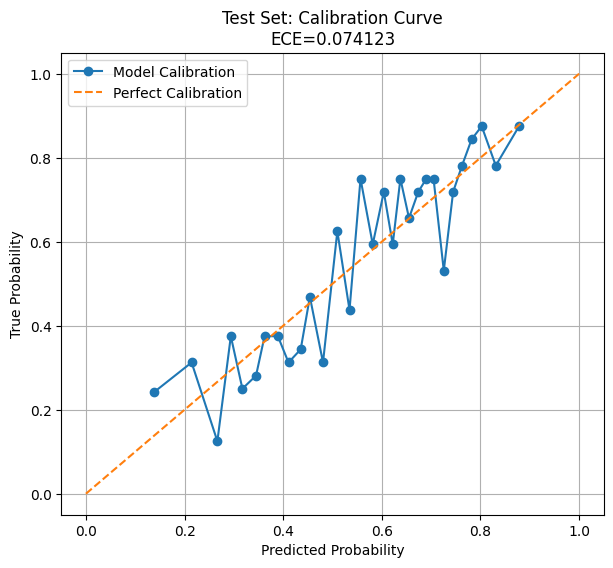

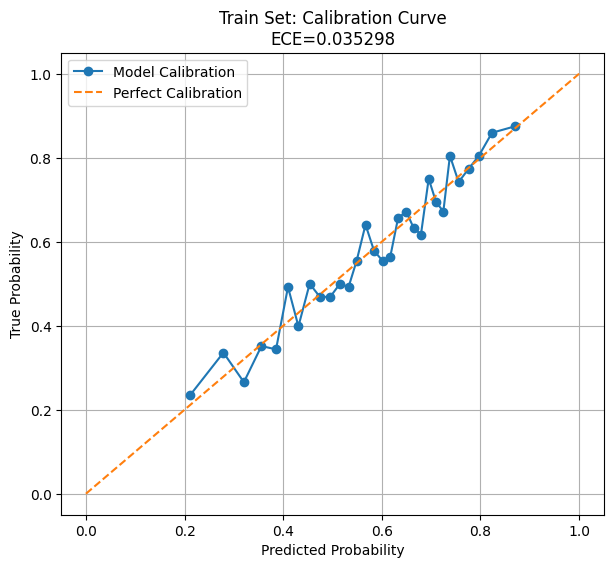

                        feature        VIF
0     sig_str_landed_total_diff  19.080523
1           head_str_total_diff  14.183345
2            avg_fight_min_diff  13.860857
3                   losses_diff   8.744575
4   sig_str_absorbed_total_diff   7.316416
5            control_total_diff   3.073538
6                      elo_diff   2.217214
7                   height_diff   1.734712
8                    reach_diff   1.703464
9                 kd_total_diff   1.676037
10                 win_pct_diff   1.665772
11               ko_losses_diff   1.540182
12         proba_fair_open_diff   1.432031
13                     age_diff   1.346489
14         td_attempted_pm_diff   1.305754
                           Logit Regression Results                           
Dep. Variable:                 winner   No. Observations:                 3840
Model:                          Logit   Df Residuals:                     3824
Method:                           MLE   Df Model:                          

In [7]:
results_open = run_logit_model(
    X_train_red_blue, y_train,
    X_test_red_blue, y_test,
    cov_type="HC3",
    n_bins=30,
    vif_func=check_vif
)

y_pred = results_open["test_pred_class"]
red_probs = results_open["test_pred_proba"]
blue_probs = 1 - red_probs
probs_2d_test = np.column_stack((blue_probs, red_probs))

df_results_test_open = save_results(df_test, probs_2d_test, r'C:\Users\jcmar\my_files\SportsBetting\data\test_logit_open.csv')
print(df_results_test_open.shape, X_test_red_blue.shape, X_test.shape)
# plot_model_metrics(y_test, y_pred, red_probs)

# y_pred = results["train_pred_class"]
# red_probs = results["train_pred_proba"]
# plot_model_metrics(y_train, y_pred, red_probs)


probs_2d_train = np.column_stack((1 - results_open["train_pred_proba"], results_open["train_pred_proba"]))
df_results_train_open = save_results(df_train, probs_2d_train, r'C:\Users\jcmar\my_files\SportsBetting\data\train_logit_open.csv')

In [9]:

p_vals_tcp = compute_tcp_pvalues(X_train, y_train, X_test)


(961,) (961,) (961,) (961, 2) (961,)
(961, 7)


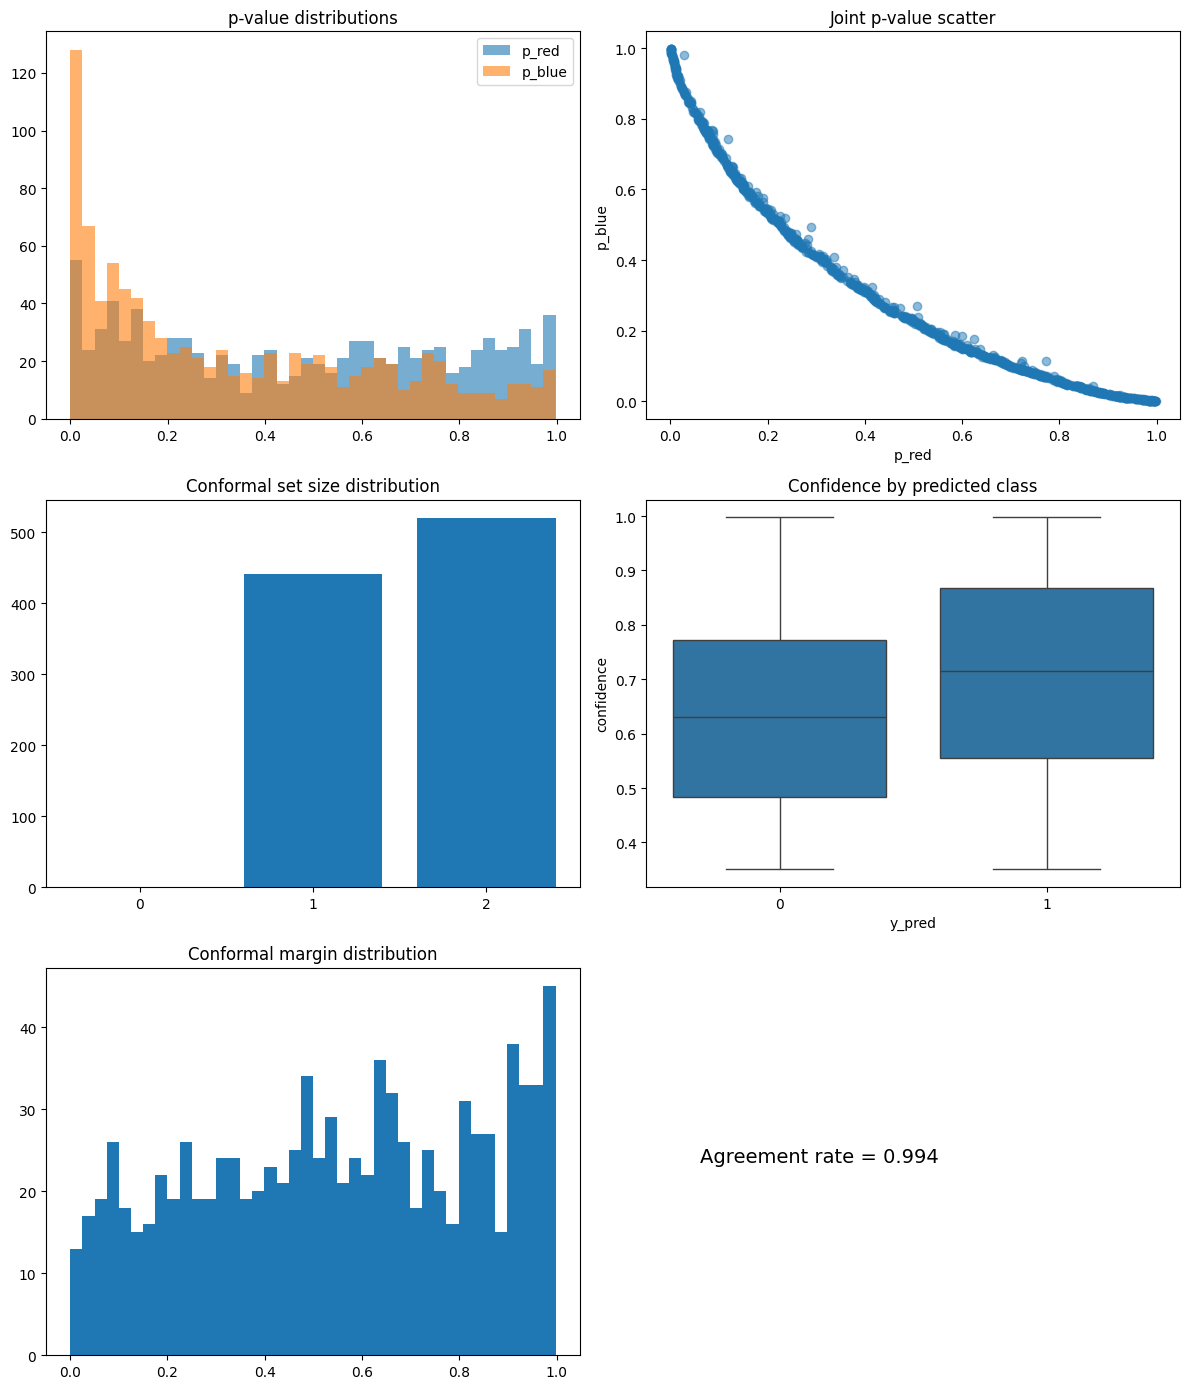

In [10]:
y_pred = results_open["test_pred_class"]
df_tcp_open = conformal_analysis(df_results_test_open, y_pred, y_test, p_vals_tcp, results_open, open_odds=True)
fp = r'C:\Users\jcmar\my_files\SportsBetting\data\open_cp.csv'
df_tcp_open.to_csv(fp)

In [160]:
df_tcp_open.head()

,y_pred,y_true,test_open_odds,p_red,p_blue,p_red_model,p_blue_model,pred_conf,confidence,uncertainty,agreement,set_size,gap
0,1,1.0,1.250000,0.369960,0.333860,0.517931,0.482069,1,0.369960,0.333860,1,2,0.036100
1,1,1.0,0.500000,0.641897,0.129908,0.653647,0.346353,1,0.641897,0.129908,1,2,0.511989
2,0,1.0,0.714286,0.289855,0.419499,0.465648,0.534352,0,0.419499,0.289855,1,2,0.129644
3,1,0.0,0.363636,0.775758,0.068511,0.717242,0.282758,1,0.775758,0.068511,1,1,0.707246
4,1,1.0,1.150000,0.363373,0.347563,0.510477,0.489523,1,0.363373,0.347563,1,2,0.015810


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

def calibrate_statsmodels_logit(
        model,
        X_train, y_train,
        X_test, y_test,
        method="platt",
        bins=10,
        figsize=(14,5)
    ):
    """
    Calibrate a statsmodels Logit model using Platt scaling or Isotonic regression.
    Produces side-by-side calibration plots for train and test sets.

    Returns dictionary with calibrated probabilities and metrics.
    """

    # ---- Add constant (statsmodels requirement) ----
    X_train_sm = sm.add_constant(X_train.copy())
    X_test_sm  = sm.add_constant(X_test.copy())

    # ---- Raw probabilities ----
    raw_train = model.predict(X_train_sm)
    raw_test  = model.predict(X_test_sm)

    raw_train = np.asarray(raw_train)
    raw_test = np.asarray(raw_test)

    # ---- Fit Calibration Model ----
    if method == "platt":
        calib_model = LogisticRegression(solver='lbfgs')
        calib_model.fit(raw_train.reshape(-1,1), y_train)

        cal_train = calib_model.predict_proba(raw_train.reshape(-1,1))[:,1]
        cal_test  = calib_model.predict_proba(raw_test.reshape(-1,1))[:,1]

    elif method == "isotonic":
        calib_model = IsotonicRegression(out_of_bounds="clip")
        calib_model.fit(raw_train, y_train)

        cal_train = calib_model.predict(raw_train)
        cal_test  = calib_model.predict(raw_test)

    else:
        raise ValueError("Method must be 'platt' or 'isotonic'")

    # ---- Metrics ----
    def compute_metrics(y_true, probs, bins=10):
        # Accuracy
        acc = accuracy_score(y_true, (probs >= 0.5).astype(int))

        # Brier score
        brier = brier_score_loss(y_true, probs)

        # Calibration curve (quantile bins)
        prob_true, prob_pred = calibration_curve(
            y_true, probs, n_bins=bins, strategy="quantile"
        )

        # ECE: each quantile bin contains equal number of samples
        K = len(prob_true)
        weights = np.ones(K) / K
        ece = np.sum(np.abs(prob_true - prob_pred) * weights)

        return acc, brier, ece, prob_true, prob_pred

    acc_tr, brier_tr, ece_tr, pt_tr, pp_tr = compute_metrics(y_train, cal_train, bins)
    acc_te, brier_te, ece_te, pt_te, pp_te = compute_metrics(y_test, cal_test, bins)

    # ---- Plot side-by-side calibration curves ----
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # TRAIN PLOT
    axes[0].plot(pp_tr, pt_tr, marker='o', label='Train Calibrated')
    axes[0].plot([0,1], [0,1], '--', color='black')
    axes[0].set_title(
        f"Train Calibration\nAcc={acc_tr:.5f} | Brier={brier_tr:.5f} | ECE={ece_tr:.6f}"
    )
    axes[0].set_xlabel("Predicted Probability")
    axes[0].set_ylabel("Observed Frequency")
    axes[0].grid(alpha=0.3)

    # TEST PLOT
    axes[1].plot(pp_te, pt_te, marker='o', label='Test Calibrated', color='orange')
    axes[1].plot([0,1], [0,1], '--', color='black')
    axes[1].set_title(
        f"Test Calibration\nAcc={acc_te:.5f} | Brier={brier_te:.5f} | ECE={ece_te:.6f}"
    )
    axes[1].set_xlabel("Predicted Probability")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "raw_train": raw_train,
        "raw_test": raw_test,
        "calibrated_train": cal_train,
        "calibrated_test": cal_test,
        "calibration_model": calib_model,
        "train_metrics": {
            "accuracy": acc_tr, "brier": brier_tr, "ece": ece_tr,
            "prob_true": pt_tr, "prob_pred": pp_tr
        },
        "test_metrics": {
            "accuracy": acc_te, "brier": brier_te, "ece": ece_te,
            "prob_true": pt_te, "prob_pred": pp_te
        }
    }

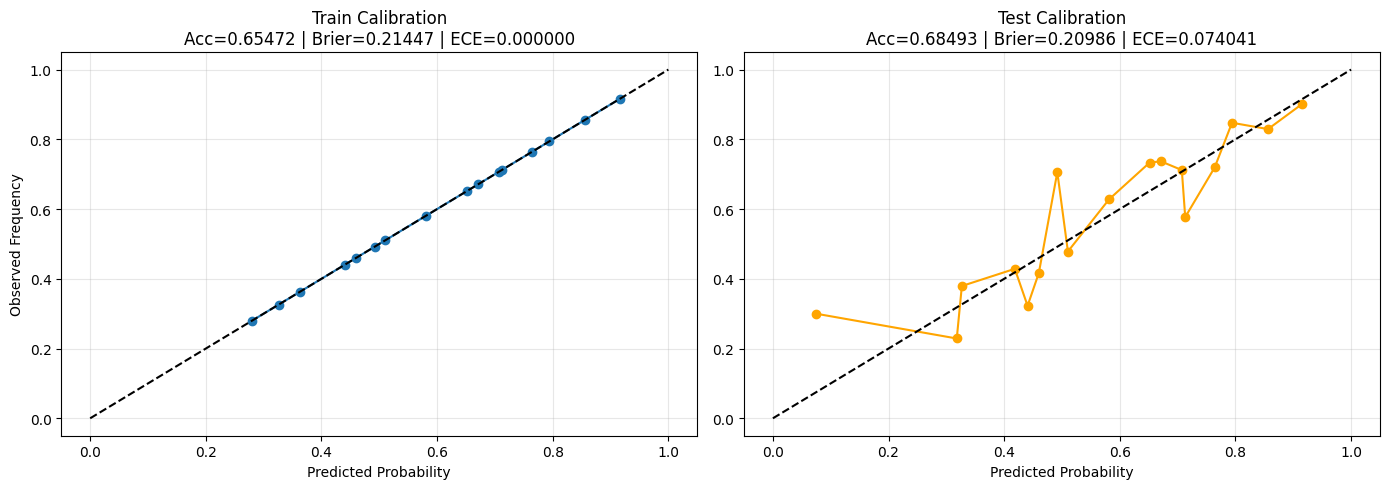

In [10]:
logit_model = results_open['model']
results_cal = calibrate_statsmodels_logit(logit_model, X_train_red_blue, y_train, X_test_red_blue, y_test, method='isotonic', bins=20)


In [11]:
print_gender_accuracy(df_results_test_open)

Accuracy for Men weight classes:   0.700
Accuracy for Women weight classes: 0.699


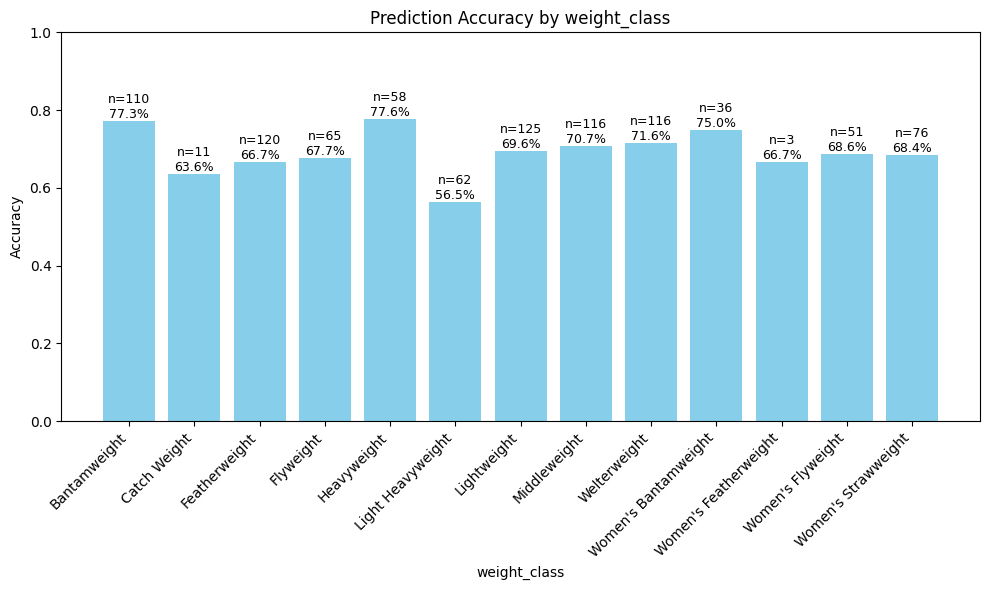

In [12]:
plot_accuracy_by_variable(df_results_test_open, 'weight_class')

<Axes: xlabel='year'>

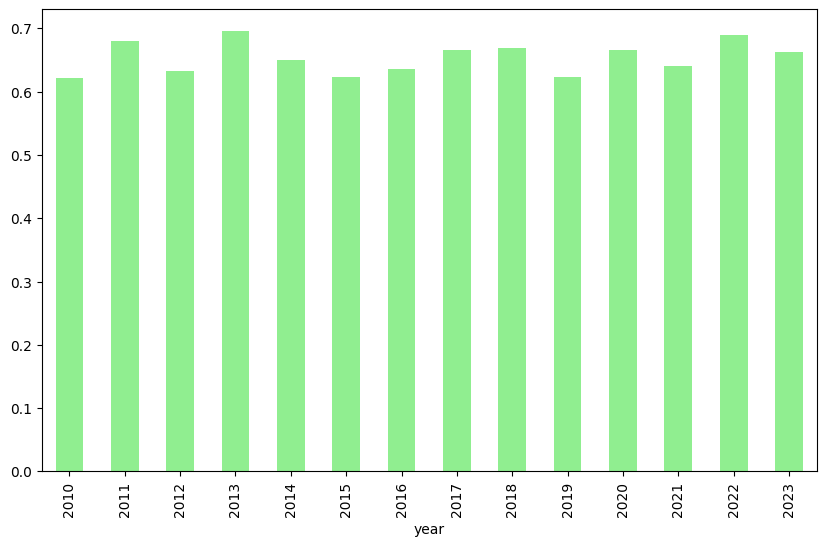

In [9]:
df_results_train_open['year'] = df_results_train_open['Date'].dt.year

accuracy_by_year = df_results_train_open.groupby('year')['correct_pred'].mean()
accuracy_by_year.plot(kind='bar', figsize=(10,6), color='lightgreen')

In [ ]:
df_results_test_open['year'] = df_results_test_open['Date'].dt.year
accuracy_by_year = df_results_test_open.groupby('year')['correct_pred'].mean()
accuracy_by_year.plot(kind='bar', figsize=(10,6), color='lightgreen')

(546, 299) (961, 299)
Sum of decimal odds for favorite predictions (adjusted): 35.18701338483632
Sum of decimal odds for underdog predictions (adjusted): 43.17002467937047
Fav bets: 440 total, 317 correct, 123 incorrect, 72.05% correct
Dog bets: 106 total, 69 correct, 37 incorrect, 65.09% correct


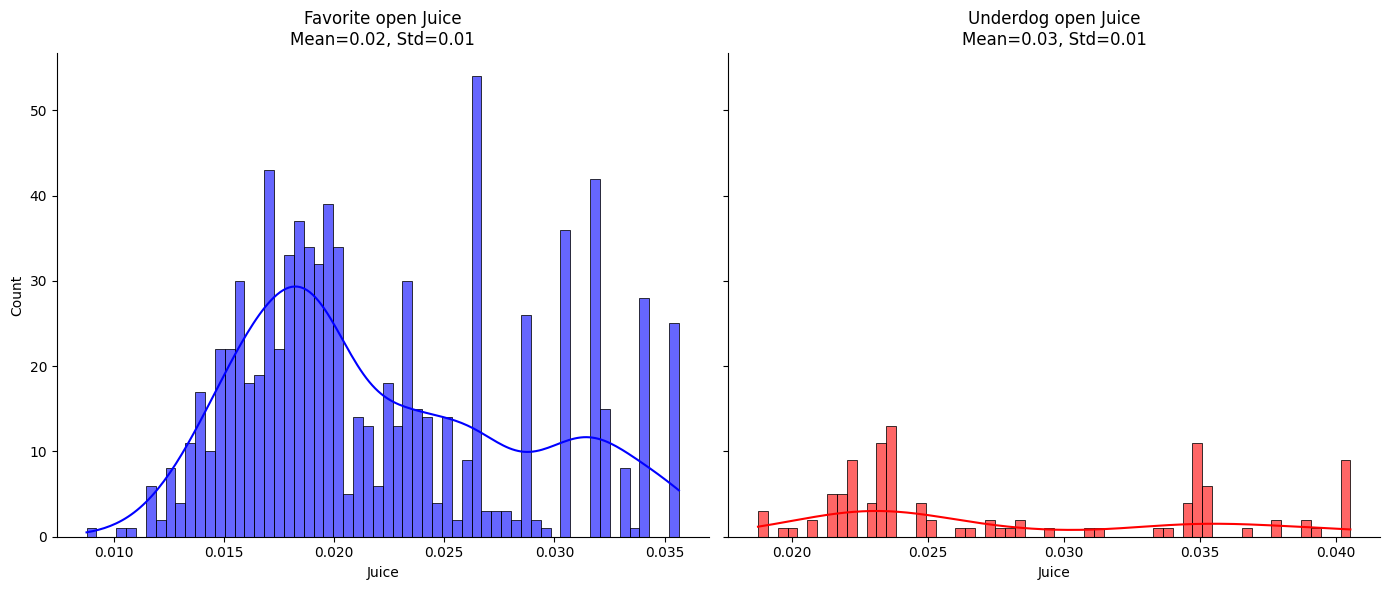

In [11]:
calc_net_odds(df_results_test_open, 'open')  
plot_juice_histogram(df_results_test_open, 'open')


In [12]:

fp = r'C:\Users\jcmar\my_files\SportsBetting\data\entire_odds_stats_2025-12-04.csv'
df_model = pd.read_csv(fp)


non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'pimp_close1_blue','pimp_close1_red','pimp_close2_blue','pimp_close2_red',
    'juice_close1_blue','juice_close1_red','juice_close2_blue','juice_close2_red',
    'winner_name',
    
    'red_fighter_odds','blue_fighter_odds',
    'dec_close1_blue','dec_close1_red','dec_close2_blue','dec_close2_red',
    'dec_fair_close1_blue','dec_fair_close1_red','dec_fair_close2_blue','dec_fair_close2_red',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'performance_bonus_winner', 'fight_otn_bonus'
] #'close1_blue','close1_red', 'close2_blue', 'close2_red'

selected_feats = ['proba_fair_close1_diff', 'proba_fair_close2_diff', 'age_diff', 'open_red', 'open_blue', 'reach_diff', 'sig_str_absorbed_total_diff', 
                  'td_attempted_pm_diff', 'elo_diff', 'sig_str_landed_total_diff',
                    'ko_losses_diff', 'win_pct_diff', 'kd_total_diff','avg_fight_min_diff', 'height_diff', 'head_str_total_diff', 'losses_diff', 'control_total_diff'
                   ]

# selected_feats = ['proba_fair_close1_diff', 'proba_fair_close2_diff', 
#                   'line_movement_close1_blue','line_movement_close1_red','line_movement_close2_blue','line_movement_close2_red',
#                     'open_red', 'open_blue']
gmm_cols = ['red_gmm_cluster', 'blue_gmm_cluster']

y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.8, random_state=42)
builder.filter_by_year(2010, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test = builder.prepare_train_test(selected_feats, clustering=None)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

X_train['open_pred'] = results_open['train_pred_class']
X_test['open_pred'] = results_open["test_pred_class"]

# X_train['red_gmm12'] = X_train['red_gmm_cluster_1'] * X_train['blue_gmm_cluster_2']
# X_train['red_gmm21'] = X_train['red_gmm_cluster_2'] * X_train['blue_gmm_cluster_1']

# X_test['red_gmm12'] = X_test['red_gmm_cluster_1'] * X_test['blue_gmm_cluster_2']
# X_test['red_gmm21'] = X_test['red_gmm_cluster_2'] * X_test['blue_gmm_cluster_1']

# X_train = X_train.drop(columns=['red_gmm_cluster_1', 'blue_gmm_cluster_1', 'red_gmm_cluster_2', 'blue_gmm_cluster_2'])
# X_test = X_test.drop(columns=['red_gmm_cluster_1', 'blue_gmm_cluster_1', 'red_gmm_cluster_2', 'blue_gmm_cluster_2'])


Filtered: kept 6577 rows from year 2010 onward.
PREPARE SHAPE: (4830, 290)
MODEL SHAPE: (4743, 290)
Categorical columns: []
Numerical columns: ['proba_fair_close1_diff', 'proba_fair_close2_diff', 'age_diff', 'open_red', 'open_blue', 'reach_diff', 'sig_str_absorbed_total_diff', 'td_attempted_pm_diff', 'elo_diff', 'sig_str_landed_total_diff', 'ko_losses_diff', 'win_pct_diff', 'kd_total_diff', 'avg_fight_min_diff', 'height_diff', 'head_str_total_diff', 'losses_diff', 'control_total_diff']


In [13]:
_, _, X_train_fav_dog, X_test_fav_dog, X_train_red_blue, X_test_red_blue, _, _ = build_train_test(X_train, X_test, y_train, y_test, open_close=False)


(3794,) (3794, 20)
(949,) (949, 20)


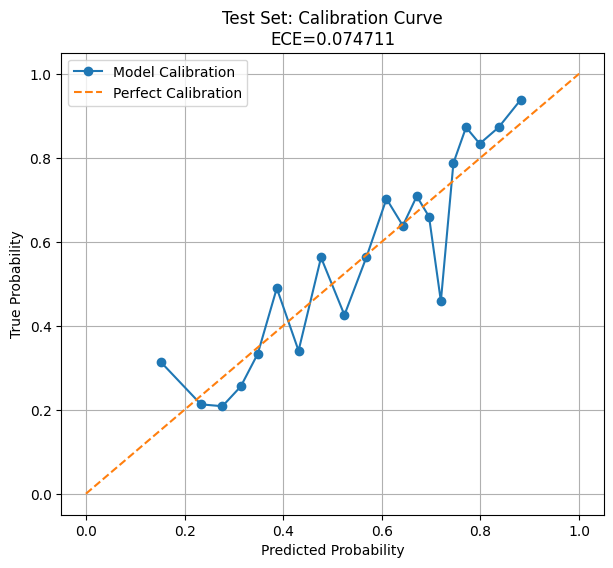

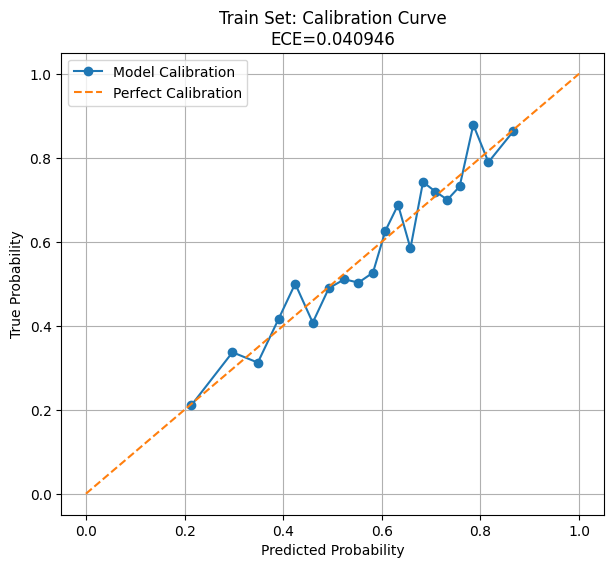

                        feature         VIF
0        proba_fair_close1_diff  576.278538
1        proba_fair_close2_diff  576.011597
2     sig_str_landed_total_diff   19.008000
3           head_str_total_diff   14.113271
4            avg_fight_min_diff   13.825560
5                   losses_diff    8.702134
6   sig_str_absorbed_total_diff    7.280883
7            control_total_diff    3.090178
8                      elo_diff    2.217274
9                   height_diff    1.730440
10                   reach_diff    1.704708
11                kd_total_diff    1.683062
12                 win_pct_diff    1.664724
13               ko_losses_diff    1.556224
14                     age_diff    1.407085
15         td_attempted_pm_diff    1.304887
16                    open_pred    1.002332
                           Logit Regression Results                           
Dep. Variable:                 winner   No. Observations:                 3794
Model:                          Logit   Df Residua

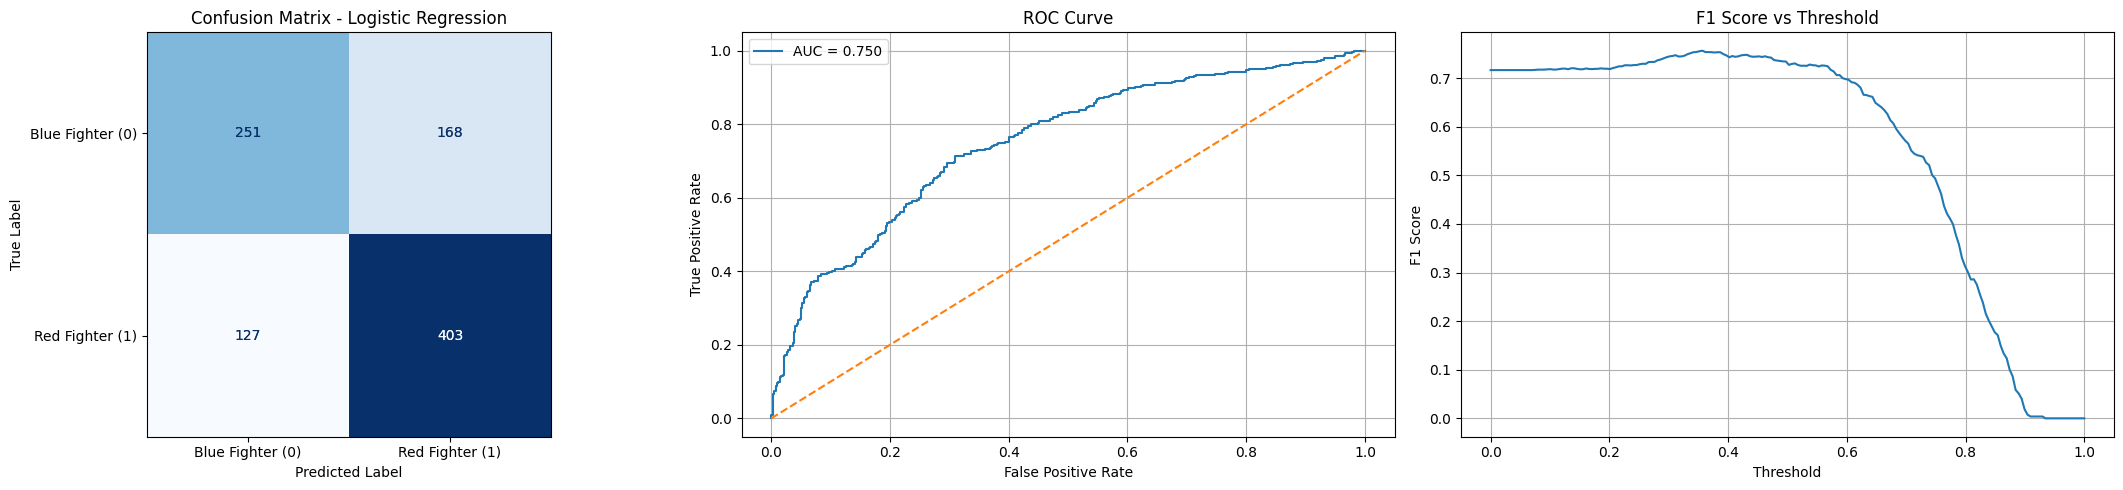

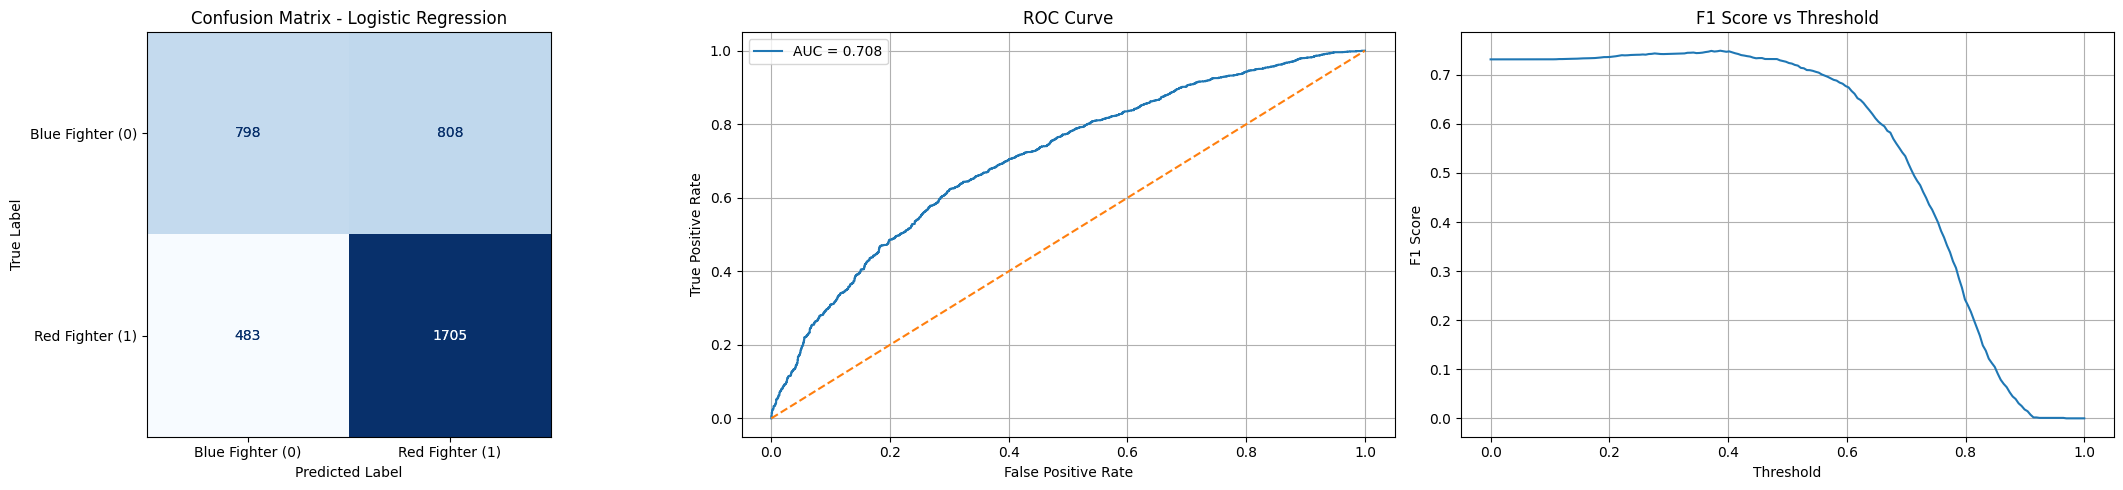

In [14]:
results = run_logit_model(
    X_train_red_blue, y_train,
    X_test_red_blue, y_test,
    cov_type="HC3",
    n_bins=20,
    vif_func=check_vif
)

y_pred = results["test_pred_class"]
red_probs = results["test_pred_proba"]
blue_probs = 1 - red_probs
probs_2d_test = np.column_stack((blue_probs, red_probs))

df_test_results = save_results(df_test, probs_2d_test, r'C:\Users\jcmar\my_files\SportsBetting\data\test_logit_close.csv')
plot_model_metrics(y_test, y_pred, red_probs)

probs_2d_train = np.column_stack((1 - results["train_pred_proba"], results["train_pred_proba"]))
df_train_results = save_results(df_train, probs_2d_train, r'C:\Users\jcmar\my_files\SportsBetting\data\train_logit_close.csv')

y_pred = results["train_pred_class"]
red_probs = results["train_pred_proba"]
plot_model_metrics(y_train, y_pred, red_probs)

In [119]:
print_gender_accuracy(df_test_results)

Accuracy for Men weight classes:   0.691
Accuracy for Women weight classes: 0.711


(589, 299) (949, 299)
Sum of decimal odds for favorite predictions (adjusted): 45.114623505104255
Sum of decimal odds for underdog predictions (adjusted): 10.52395070948469
Fav bets: 526 total, 379 correct, 147 incorrect, 72.05% correct
Dog bets: 63 total, 34 correct, 29 incorrect, 53.97% correct
(382, 299) (949, 299)
Sum of decimal odds for favorite predictions (adjusted): 13.100180440623882
Sum of decimal odds for underdog predictions (adjusted): 4.916066521407967
Fav bets: 325 total, 233 correct, 92 incorrect, 71.69% correct
Dog bets: 57 total, 31 correct, 26 incorrect, 54.39% correct


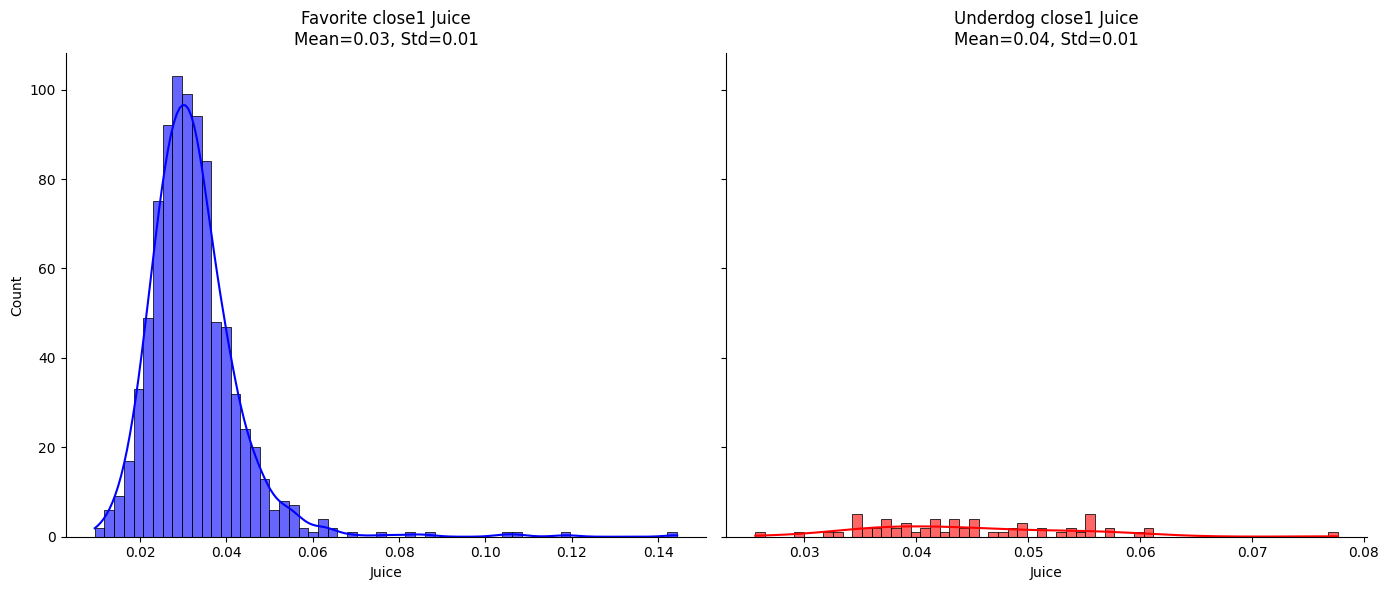

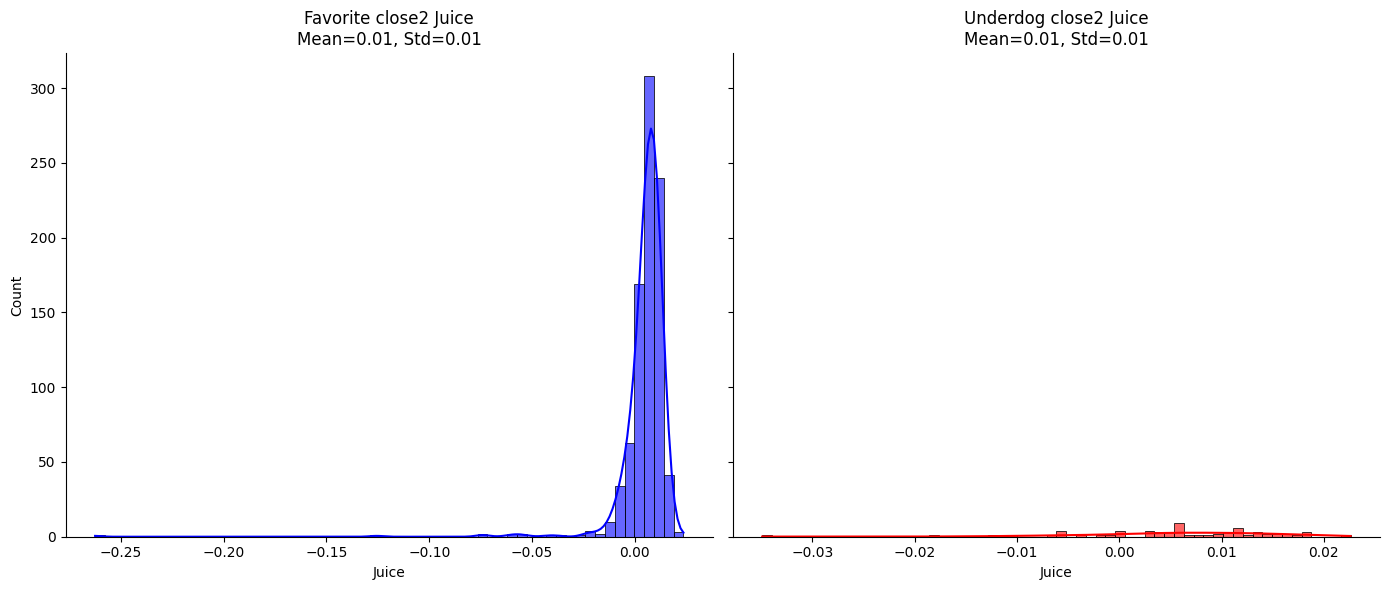

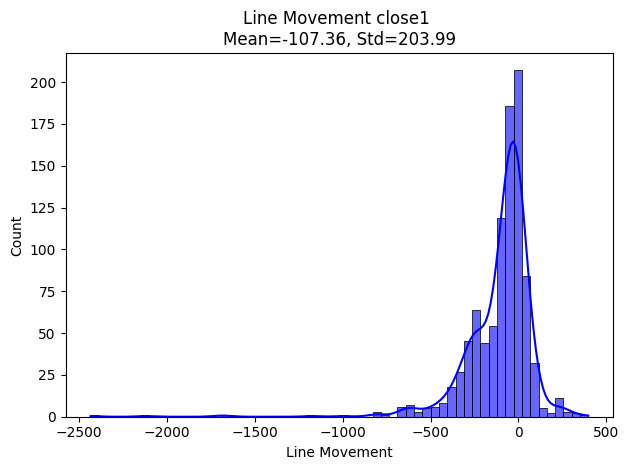

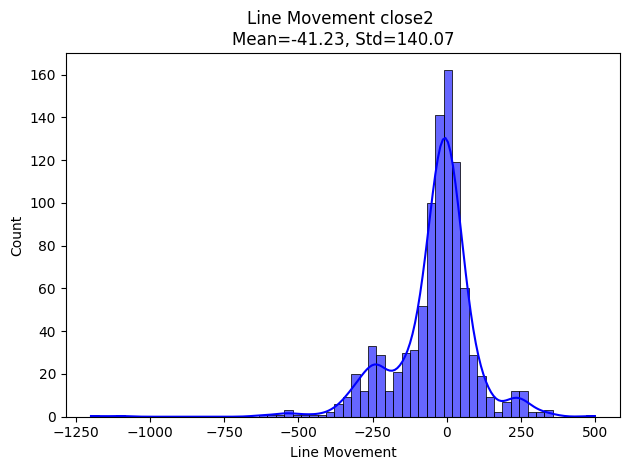

In [15]:
calc_net_odds(df_test_results, 'close2')
calc_net_odds(df_test_results, 'close1')
plot_juice_histogram(df_test_results, 'close1')
plot_juice_histogram(df_test_results, 'close2')

plot_line_movement(df_test_results, 'close1')
plot_line_movement(df_test_results, 'close2')

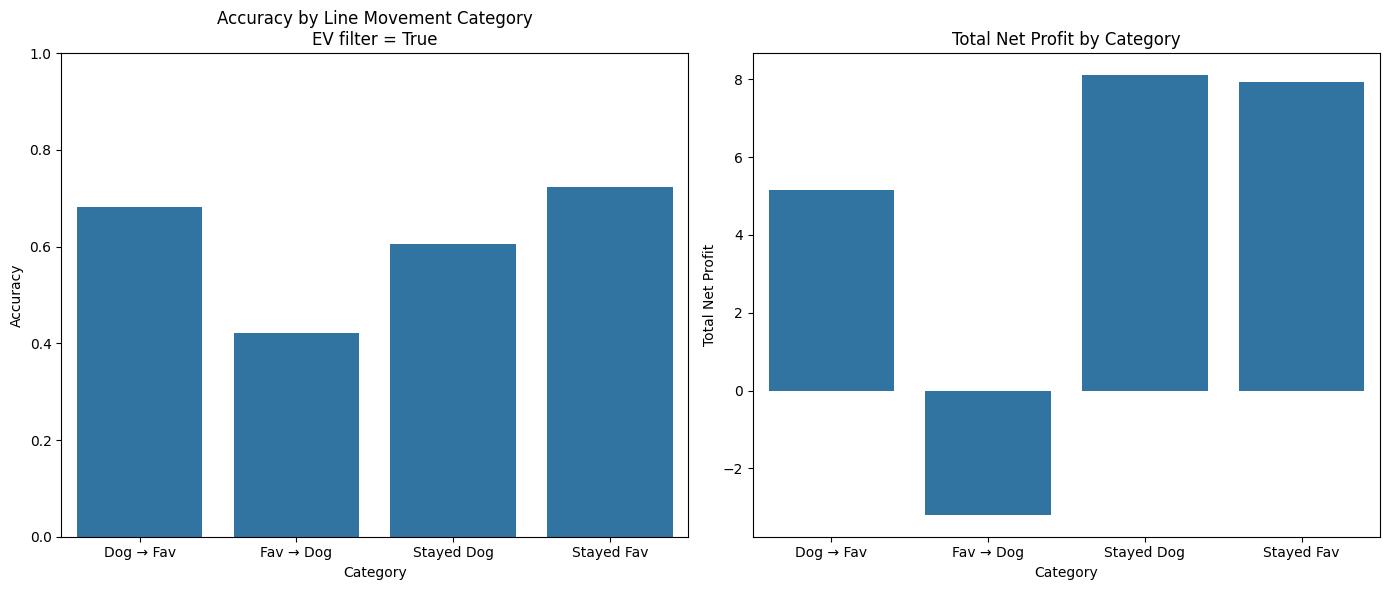

,movement_category,accuracy,n,total_profit,mean_EV
0,Dog → Fav,0.680851,47,5.155982,0.102908
1,Fav → Dog,0.421053,19,-3.192542,0.141702
2,Stayed Dog,0.605263,38,8.108609,0.147310
3,Stayed Fav,0.723022,278,7.944198,0.067206


In [16]:
analyze_line_movement_perf(df_test_results, 'close1')

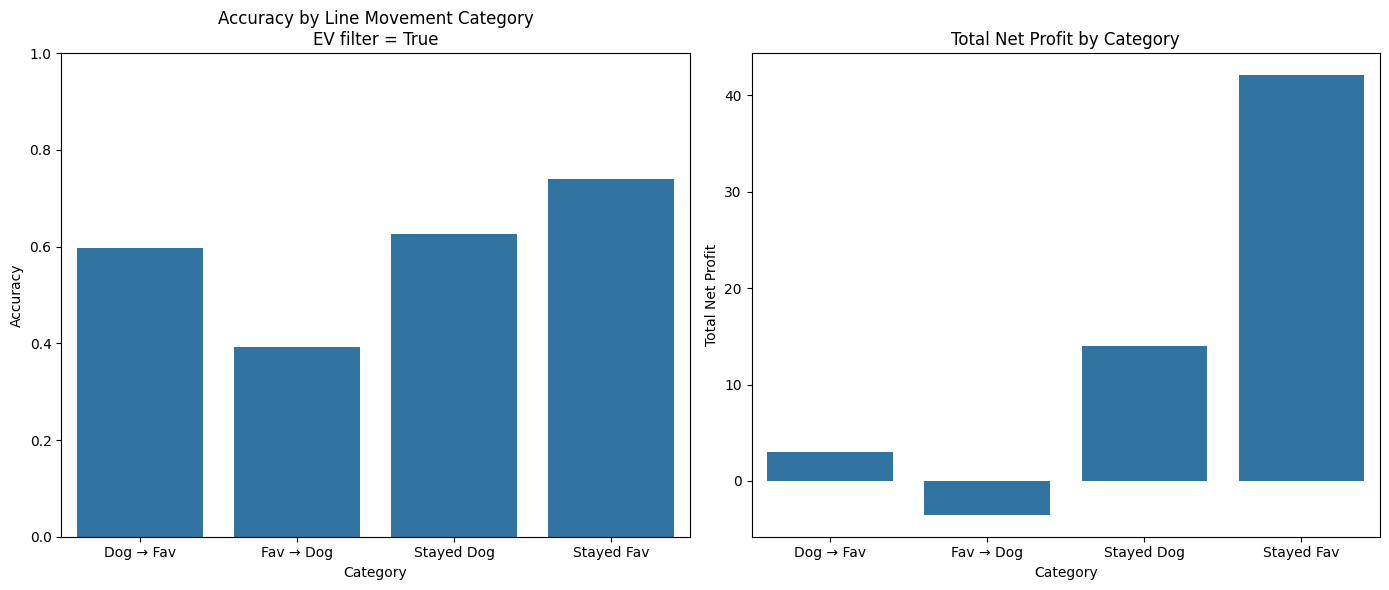

,movement_category,accuracy,n,total_profit,mean_EV
0,Dog → Fav,0.597222,72,2.999393,0.142861
1,Fav → Dog,0.391304,23,-3.510000,0.219217
2,Stayed Dog,0.625000,40,14.033951,0.222362
3,Stayed Fav,0.740088,454,42.115231,0.088210


In [17]:
analyze_line_movement_perf(df_test_results, 'close2')

In [83]:
results

{'train_pred_proba': 0       0.473990
 1       0.318636
 2       0.849828
 3       0.593804
 4       0.496764
           ...   
 3650    0.621909
 3651    0.490047
 3652    0.623343
 3653    0.322262
 3654    0.592688
 Length: 3655, dtype: float64,
 'test_pred_proba': 0      0.722782
 1      0.511741
 2      0.535319
 3      0.787068
 4      0.394621
          ...   
 909    0.703957
 910    0.426345
 911    0.533460
 912    0.404335
 913    0.578248
 Length: 914, dtype: float64,
 'test_pred_class': 0      1
 1      1
 2      1
 3      1
 4      0
       ..
 909    1
 910    0
 911    1
 912    0
 913    1
 Length: 914, dtype: int64,
 'train_pred_class': 0       0
 1       0
 2       1
 3       1
 4       0
        ..
 3650    1
 3651    0
 3652    1
 3653    0
 3654    1
 Length: 3655, dtype: int64,
 'model': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x2933e8e14d0>}

In [124]:
conf = 1 - min(p_values_tcp[i])
y_pred = results["test_pred_class"]

print(p_values_tcp.shape, y_pred.shape)

(949, 2) (949,)


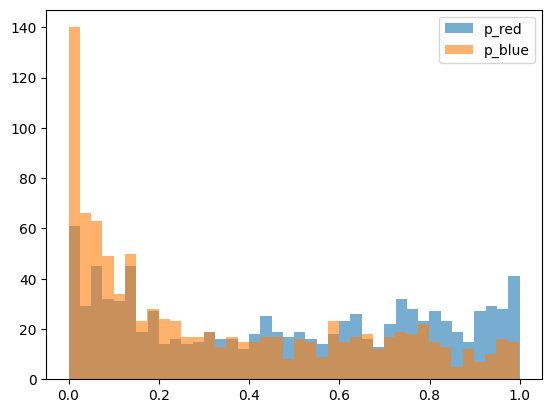

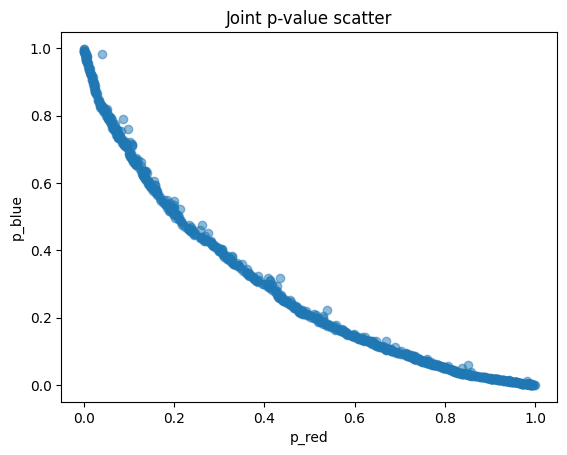

Agreement with model prediction: 0.9884088514225501


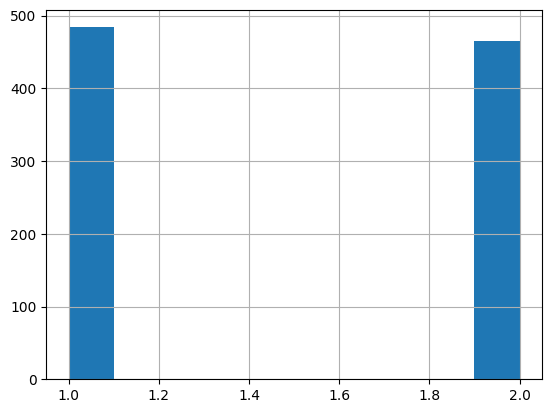

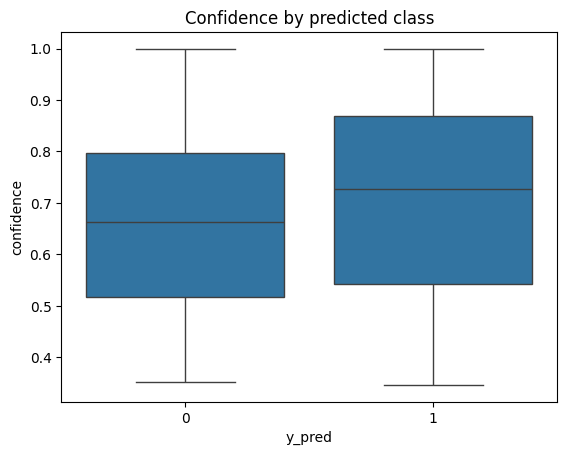

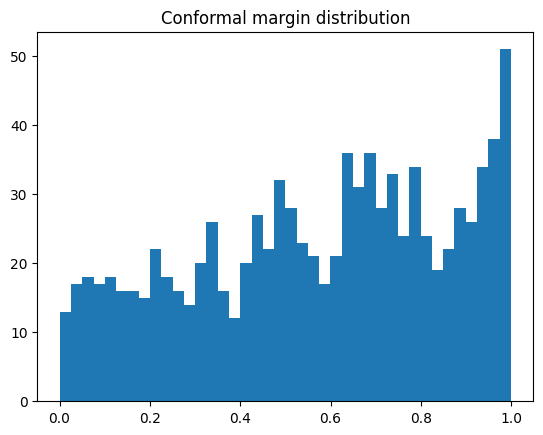

In [ ]:

test_choice_odds1 = np.where(df_test_results['pred_winner']==1, df_test_results['dec_close1_red']-1, df_test_results['dec_close1_blue']-1)
test_choice_odds2 = np.where(df_test_results['pred_winner']==1, df_test_results['dec_close2_red']-1, df_test_results['dec_close2_blue']-1)

df_tcp = pd.DataFrame({
    "y_pred": y_pred,
    'y_true':y_test,
    'choice_netodds_close1': test_choice_odds1, 
    'choice_netodds_close2': test_choice_odds2, 
    "p_red":  p_values_tcp[:, 1],
    "p_blue": p_values_tcp[:, 0],
    'p_red_model':results['test_pred_proba'],
    'p_blue_model': 1-results['test_pred_proba']
})



# Conformal prediction decision
df_tcp["pred_conf"] = df_tcp[["p_red", "p_blue"]].idxmax(axis=1).map({"p_red":1, "p_blue":0})

# confidence measure
df_tcp["confidence"] = df_tcp[["p_red","p_blue"]].max(axis=1)

# uncertainty measure
df_tcp["uncertainty"] = df_tcp[["p_red","p_blue"]].min(axis=1)

# does the model prediction match conformal prediction?
df_tcp["agreement"] = (df_tcp["y_pred"] == df_tcp["pred_conf"]).astype(int)

plt.hist(df_tcp["p_red"], bins=40, alpha=0.6, label="p_red")
plt.hist(df_tcp["p_blue"], bins=40, alpha=0.6, label="p_blue")
plt.legend()
plt.show()


plt.scatter(df_tcp["p_red"], df_tcp["p_blue"], alpha=0.5)
plt.xlabel("p_red")
plt.ylabel("p_blue")
plt.title("Joint p-value scatter")
plt.show()


agreement_rate = df_tcp["agreement"].mean()
print("Agreement with model prediction:", agreement_rate)

alpha = 0.1
df_tcp["set_size"] = (df_tcp["p_red"] >= alpha).astype(int) + \
                      (df_tcp["p_blue"] >= alpha).astype(int)

df_tcp["set_size"].value_counts()
df_tcp["set_size"].hist()
plt.show()


sns.boxplot(x="y_pred", y="confidence", data=df_tcp)
plt.title("Confidence by predicted class")
plt.show()

df_tcp["gap"] = np.abs(df_tcp["p_red"] - df_tcp["p_blue"])

plt.hist(df_tcp["gap"], bins=40)
plt.title("Conformal margin distribution")
plt.show()

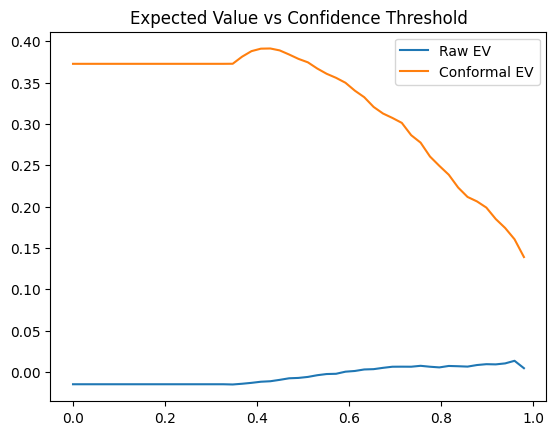

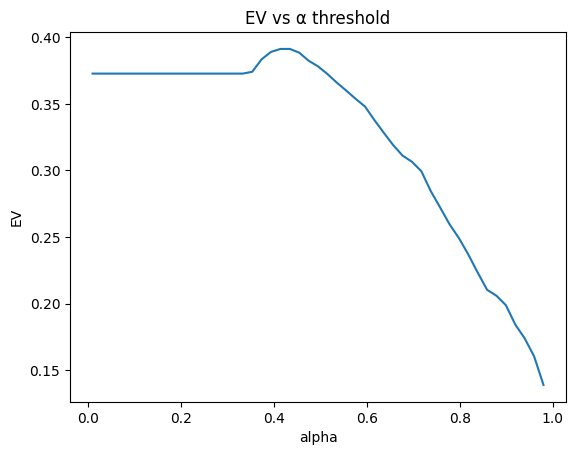

alpha      0.434286
ev         0.391279
count    838.000000
Name: 21, dtype: float64
EV Difference: 0.3876565391932628
95% CI: 0.37817856243377884 0.3971848703901426
Cohen d: 2.4851652315133492


In [ ]:
raw_red  = df_tcp["p_red_model"]  * df_tcp["p_red"]
raw_blue = df_tcp["p_blue_model"] * df_tcp["p_blue"]
total = raw_red + raw_blue
df_tcp["prob_conf_red"]  = raw_red  / total
df_tcp["prob_conf_blue"] = raw_blue / total


df_tcp["prob_conf_red"] = (
    df_tcp["p_red_model"] ** (1 / df_tcp["p_red"])
)

df_tcp["prob_conf_blue"] = (
    df_tcp["p_blue_model"] ** (1 / df_tcp["p_blue"])
)

total = df_tcp["prob_conf_red"] + df_tcp["prob_conf_blue"]

df_tcp["prob_conf_red"]  /= total
df_tcp["prob_conf_blue"] /= total


df_tcp["ev_conf"] = np.where(
    df_tcp["y_pred"] == 1,
    df_tcp["prob_conf_red"]  * df_tcp["choice_netodds_close1"] - (1 - df_tcp["prob_conf_red"]),
    df_tcp["prob_conf_blue"] * df_tcp["choice_netodds_close1"] - (1 - df_tcp["prob_conf_blue"])
)

df_tcp["ev_raw"] = np.where(
    df_tcp["y_pred"] == 1,   # model predicts red
    df_tcp["p_red_model"] * (df_tcp["choice_netodds_close1"] ) - (1 - df_tcp["p_red_model"]),
    df_tcp["p_blue_model"] * (df_tcp["choice_netodds_close1"]) - (1 - df_tcp["p_blue_model"])
)


xs = np.linspace(0.0,1.0,50)
ys_raw  = [df_tcp[df_tcp["confidence"]>=x]["ev_raw"].mean() for x in xs]
ys_conf = [df_tcp[df_tcp["confidence"]>=x]["ev_conf"].mean() for x in xs]

plt.plot(xs, ys_raw, label="Raw EV")
plt.plot(xs, ys_conf, label="Conformal EV")
plt.legend()
plt.title("Expected Value vs Confidence Threshold")
plt.show()



alphas = np.linspace(0.01, 1, 50)
results = []

for alpha in alphas:
    df_alpha = df_tcp[(df_tcp["p_red"]>=alpha) | (df_tcp["p_blue"]>=alpha)]
    mean_ev  = df_alpha["ev_conf"].mean()
    n        = len(df_alpha)
    results.append((alpha, mean_ev, n))

opt_df = pd.DataFrame(results, columns=["alpha","ev","count"])


plt.plot(opt_df["alpha"], opt_df["ev"])
plt.title("EV vs α threshold")
plt.xlabel("alpha")
plt.ylabel("EV")
plt.show()

best_alpha = opt_df.iloc[opt_df["ev"].idxmax()]
print(best_alpha)



def bootstrap_diff(df, n_iter=2000):

    diffs = []

    for _ in range(n_iter):
        sample = df.sample(frac=1, replace=True)
        diffs.append(
            sample["ev_conf"].mean() - sample["ev_raw"].mean()
        )

    return np.array(diffs)

diffs = bootstrap_diff(df_tcp)

ci_low  = np.percentile(diffs, 2.5)
ci_high = np.percentile(diffs, 97.5)
mean_diff = diffs.mean()

print("EV Difference:", mean_diff)
print("95% CI:", ci_low, ci_high)

d = (
    (df_tcp["ev_conf"].mean() - df_tcp["ev_raw"].mean()) /
    np.sqrt(0.5*(df_tcp["ev_conf"].var() + df_tcp["ev_raw"].var()))
)

print("Cohen d:", d)



In [127]:
# accuracy
acc_size1 = (df_tcp.loc[df_tcp["set_size"] == 1, "y_pred"] == 
             df_tcp.loc[df_tcp["set_size"] == 1, "y_true"]).mean()

acc_size2 = (df_tcp.loc[df_tcp["set_size"] == 2, "y_pred"] == 
             df_tcp.loc[df_tcp["set_size"] == 2, "y_true"]).mean()

# net odds (mean)
net1_side1 = df_tcp.loc[df_tcp["set_size"] == 1, "choice_netodds_close1"].mean()
net2_side1 = df_tcp.loc[df_tcp["set_size"] == 2, "choice_netodds_close1"].mean()

net1_side2 = df_tcp.loc[df_tcp["set_size"] == 1, "choice_netodds_close2"].mean()
net2_side2 = df_tcp.loc[df_tcp["set_size"] == 2, "choice_netodds_close2"].mean()


print("🔹 Accuracy (set size = 1):", acc_size1)
print("🔹 Accuracy (set size = 2):", acc_size2)

print("\n🔹 Mean Net Odds Close 1 (size 1):", net1_side1)
print("🔹 Mean Net Odds Close 1 (size 2):", net2_side1)

print("\n🔹 Mean Net Odds Close 2 (size 1):", net1_side2)
print("🔹 Mean Net Odds Close 2 (size 2):", net2_side2)

🔹 Accuracy (set size = 1): 0.7747933884297521
🔹 Accuracy (set size = 2): 0.610752688172043

🔹 Mean Net Odds Close 1 (size 1): 0.30552021096754617
🔹 Mean Net Odds Close 1 (size 2): 0.608954738693411

🔹 Mean Net Odds Close 2 (size 1): 0.37020249427535734
🔹 Mean Net Odds Close 2 (size 2): 0.7060232704538029


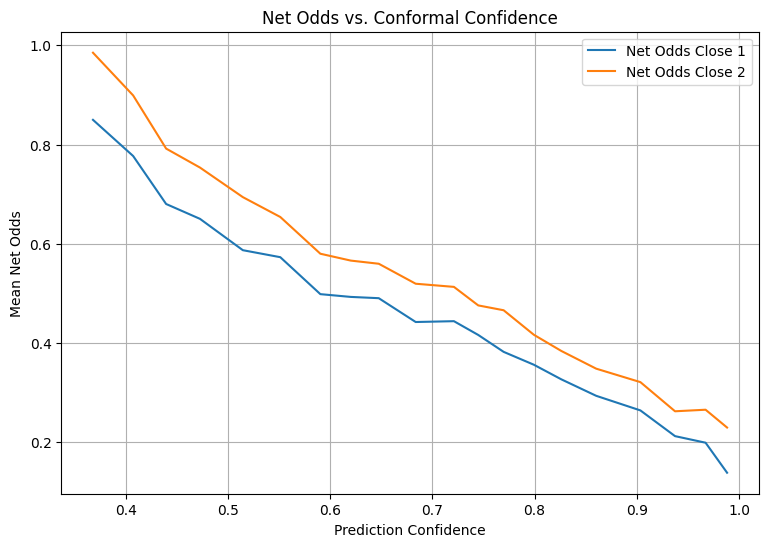

In [128]:
df_tcp["conf_bin"] = pd.qcut(df_tcp["confidence"], q=20, labels=False)
summary = df_tcp.groupby("conf_bin")[
    ["choice_netodds_close1", "choice_netodds_close2"]
].mean()

summary["count"] = df_tcp.groupby("conf_bin").size()
summary["mean_conf"] = df_tcp.groupby("conf_bin")["confidence"].mean()
summary = summary.reset_index()

plt.figure(figsize=(9,6))
plt.plot(summary["mean_conf"], summary["choice_netodds_close1"], label="Net Odds Close 1")
plt.plot(summary["mean_conf"], summary["choice_netodds_close2"], label="Net Odds Close 2")
plt.xlabel("Prediction Confidence")
plt.ylabel("Mean Net Odds")
plt.title("Net Odds vs. Conformal Confidence")
plt.legend()
plt.grid(True)
plt.show()

In [129]:
disagree = df_tcp[df_tcp["y_pred"] != df_tcp["pred_conf"]]
print(disagree.head())
print(disagree.shape)

print('Pred Model Accuracy: ', (disagree['y_true'] == disagree['y_pred']).mean())
print('Pred CP Accuracy: ', (disagree['y_true'] == disagree['pred_conf']).mean())

     y_pred  y_true  choice_netodds_close1  choice_netodds_close2     p_red  \
20        0     1.0               0.724638               0.833333  0.352569   
95        1     1.0               0.555556               0.666667  0.333860   
213       1     1.0               1.430000               1.700000  0.345718   
233       1     1.0               0.588235               0.800000  0.350988   
342       1     1.0               0.833333               1.100000  0.321739   

       p_blue  p_red_model  p_blue_model  pred_conf  confidence  uncertainty  \
20   0.339394     0.491537      0.508463          1    0.352569     0.339394   
95   0.355204     0.503201      0.496799          0    0.355204     0.333860   
213  0.346509     0.511898      0.488102          0    0.346509     0.345718   
233  0.358103     0.524442      0.475558          0    0.358103     0.350988   
342  0.370751     0.500101      0.499899          0    0.370751     0.321739   

     agreement  set_size       gap  prob_con

C:\Users\jcmar\AppData\Local\Temp\ipykernel_18480\2354865431.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary = df_tcp.groupby("bin").agg({


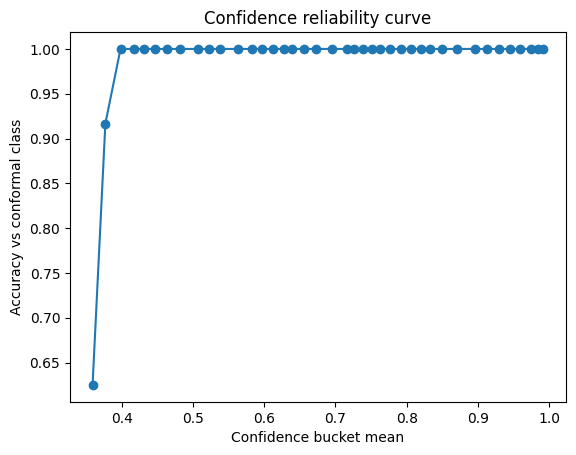

In [130]:
df_tcp["bin"] = pd.qcut(df_tcp["confidence"], 40, duplicates="drop")
df_summary = df_tcp.groupby("bin").agg({
    "confidence": "mean",
    "agreement": "mean"
})

plt.plot(df_summary["confidence"], df_summary["agreement"], marker='o')
plt.xlabel("Confidence bucket mean")
plt.ylabel("Accuracy vs conformal class")
plt.title("Confidence reliability curve")
plt.show()

In [132]:
fp = r'C:\Users\jcmar\my_files\SportsBetting\data\close_cp.csv'
df_tcp.to_csv(fp)

In [131]:


def stack_close_features(df,
                         other_cols=['open_pred']):
    close1_cols = [
        'proba_fair_close1_diff',
        'line_movement_close1_blue',
        'line_movement_close1_red'
    ]

    close2_cols = [
        'proba_fair_close2_diff',
        'line_movement_close2_blue',
        'line_movement_close2_red'
    ]

    rename_map_close1 = {
        'proba_fair_close1_diff': 'proba_fair_diff',
        'line_movement_close1_blue': 'line_movement_blue',
        'line_movement_close1_red': 'line_movement_red'
    }

    rename_map_close2 = {
        'proba_fair_close2_diff': 'proba_fair_diff',
        'line_movement_close2_blue': 'line_movement_blue',
        'line_movement_close2_red': 'line_movement_red'
    }

    df_close1 = df[close1_cols + other_cols].copy()
    df_close1 = df_close1.rename(columns=rename_map_close1)
    df_close2 = df[close2_cols + other_cols].copy()
    df_close2 = df_close2.rename(columns=rename_map_close2)
    return pd.concat([df_close1, df_close2], ignore_index=True)


def add_gaussian_noise(df, columns, std=0.01, random_state=None):
    """
    Add Gaussian noise N(0, std^2) to the specified columns in a copy of df.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    columns : list
        Columns to apply noise to.
    std : float
        Standard deviation of the Gaussian noise.
    random_state : int or None
        Reproducibility.
        
    Returns
    -------
    df_noisy : pd.DataFrame
        DataFrame with noise added.
    """
    rng = np.random.default_rng(random_state)
    df_noisy = df.copy()

    for col in columns:
        noise = rng.normal(loc=0.0, scale=std, size=len(df))
        df_noisy[col] = df_noisy[col] + noise

    return df_noisy




In [ ]:

fp = r'C:\Users\jcmar\my_files\SportsBetting\data\entire_odds_stats_2025-12-04.csv'
df_model = pd.read_csv(fp)


non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'pimp_close1_blue','pimp_close1_red','pimp_close2_blue','pimp_close2_red',
    'juice_close1_blue','juice_close1_red','juice_close2_blue','juice_close2_red',
    'winner_name',
    
    'red_fighter_odds','blue_fighter_odds',
    'dec_close1_blue','dec_close1_red','dec_close2_blue','dec_close2_red',
    'dec_fair_close1_blue','dec_fair_close1_red','dec_fair_close2_blue','dec_fair_close2_red',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'performance_bonus_winner', 'fight_otn_bonus'
] 
#'close1_blue','close1_red', 'close2_blue', 'close2_red'

# selected_feats = ['proba_fair_close1_diff', 'age_diff', 'sig_str_absorbed_pm_diff', 'win_pct_diff', 'ko_losses_diff', 'kd_pm_diff', 'control_total_diff',
#                    'td_attempted_pm_diff', 'open_red', 'open_blue', 
#                   'reach_diff', 'win_streak_diff', 'td_defense_pct_diff', 'months_since_diff',
#                     'glicko_diff', 'decision_losses_diff', 'sub_losses_diff', 'womens_fight'
#                    ]


selected_feats = ['proba_fair_close1_diff', 'proba_fair_close2_diff', 
                  'line_movement_close1_blue','line_movement_close1_red','line_movement_close2_blue','line_movement_close2_red',
                   'open_red', 'open_blue','reach_diff', 'sig_str_absorbed_total_diff', 
                  'td_attempted_pm_diff', 'elo_diff', 'sig_str_landed_total_diff',
                    'ko_losses_diff', 'win_pct_diff', 'kd_total_diff','avg_fight_min_diff', 'height_diff', 'head_str_total_diff', 'losses_diff', 'control_total_diff']


other_cols = ['proba_diff_open','open_pred', 'open_red', 'open_blue','reach_diff', 'sig_str_absorbed_total_diff', 
                  'td_attempted_pm_diff', 'elo_diff', 'sig_str_landed_total_diff',
                    'ko_losses_diff', 'win_pct_diff', 'kd_total_diff','avg_fight_min_diff',  'control_total_diff']

gmm_cols = ['red_gmm_cluster', 'blue_gmm_cluster']

y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.8, random_state=42)
builder.filter_by_year(2011, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test = builder.prepare_train_test(selected_feats, clustering=None)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

X_train['open_pred'] = results_open['train_pred_class']
X_test['open_pred'] = results_open["test_pred_class"]

X_train['proba_red'] = results_open['train_pred_proba']
X_train['proba_blue'] = 1-results_open['train_pred_proba']
X_test['proba_red'] = results_open['test_pred_proba']
X_test['proba_blue'] = 1-results_open['test_pred_proba']

X_train['proba_diff_open'] = X_train['proba_red'] - X_train['proba_blue']
X_test['proba_diff_open'] = X_test['proba_red'] - X_test['proba_blue']

print(X_train.isna().sum().sum(), X_test.isna().sum().sum())
gn_feats = ['proba_fair_diff',  'line_movement_blue','line_movement_red', 'proba_diff_open']

X_train = stack_close_features(X_train, other_cols=other_cols)
X_test = stack_close_features(X_test, other_cols=other_cols)

X_train = add_gaussian_noise(X_train, columns=gn_feats, std=.02)

y_train = pd.concat([y_train, y_train], ignore_index=True)
y_test  = pd.concat([y_test, y_test], ignore_index=True)

print(y_train.isna().sum().sum(), y_test.isna().sum().sum())
print(y_train.shape, X_train.shape)

X_train['line_movement_diff'] = X_train['line_movement_red'] - X_train['line_movement_blue']
X_test['line_movement_diff'] = X_test['line_movement_red'] - X_test['line_movement_blue']

X_train = X_train.drop(columns=['line_movement_red', 'line_movement_blue'])
X_test = X_test.drop(columns=['line_movement_red', 'line_movement_blue'])

# X_train['red_gmm12'] = X_train['red_gmm_cluster_1'] * X_train['blue_gmm_cluster_2']
# X_train['red_gmm21'] = X_train['red_gmm_cluster_2'] * X_train['blue_gmm_cluster_1']

# X_test['red_gmm12'] = X_test['red_gmm_cluster_1'] * X_test['blue_gmm_cluster_2']
# X_test['red_gmm21'] = X_test['red_gmm_cluster_2'] * X_test['blue_gmm_cluster_1']

# X_train = X_train.drop(columns=['red_gmm_cluster_1', 'blue_gmm_cluster_1', 'red_gmm_cluster_2', 'blue_gmm_cluster_2'])
# X_test = X_test.drop(columns=['red_gmm_cluster_1', 'blue_gmm_cluster_1', 'red_gmm_cluster_2', 'blue_gmm_cluster_2'])


Filtered: kept 6331 rows from year 2011 onward.
PREPARE SHAPE: (4654, 290)
MODEL SHAPE: (4569, 290)
Categorical columns: []
Numerical columns: ['proba_fair_close1_diff', 'proba_fair_close2_diff', 'line_movement_close1_blue', 'line_movement_close1_red', 'line_movement_close2_blue', 'line_movement_close2_red', 'open_red', 'open_blue', 'reach_diff', 'sig_str_absorbed_total_diff', 'td_attempted_pm_diff', 'elo_diff', 'sig_str_landed_total_diff', 'ko_losses_diff', 'win_pct_diff', 'kd_total_diff', 'avg_fight_min_diff', 'height_diff', 'head_str_total_diff', 'losses_diff', 'control_total_diff']
0 0
0 0
(7310,) (7310, 17)


(7310,) (7310, 17)
(1828,) (1828, 17)


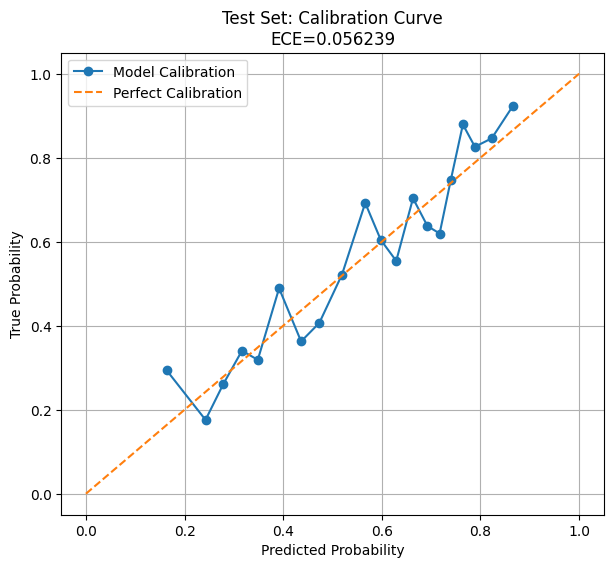

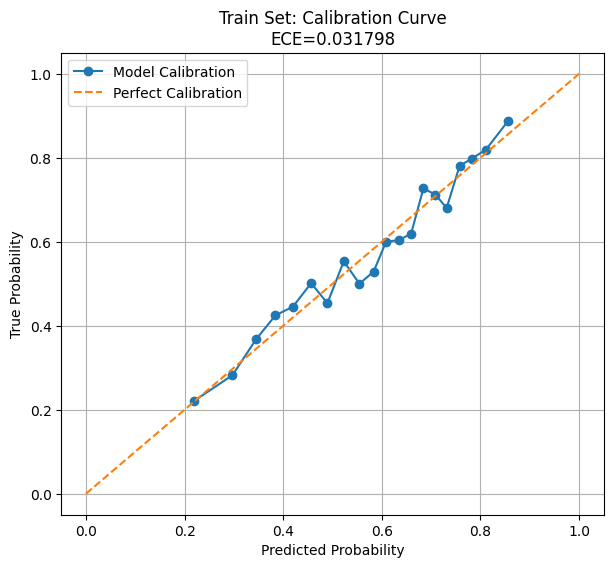

                        feature       VIF
0            avg_fight_min_diff  8.633071
1   sig_str_absorbed_total_diff  6.821622
2     sig_str_landed_total_diff  6.273143
3            control_total_diff  3.014151
4               proba_diff_open  2.479966
5                     open_pred  2.474045
6               proba_fair_diff  1.894971
7                      elo_diff  1.827427
8                 kd_total_diff  1.625125
9                  win_pct_diff  1.542241
10               ko_losses_diff  1.424237
11           line_movement_diff  1.412103
12         td_attempted_pm_diff  1.293929
13                   reach_diff  1.053645
                           Logit Regression Results                           
Dep. Variable:                 winner   No. Observations:                 7310
Model:                          Logit   Df Residuals:                     7295
Method:                           MLE   Df Model:                           14
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:

In [38]:
_, _, X_train_fav_dog, X_test_fav_dog, X_train_red_blue, X_test_red_blue, _, _ = build_train_test(X_train, X_test, y_train, y_test, open_close=False)


results = run_logit_model(
    X_train_red_blue, y_train,
    X_test_red_blue, y_test,
    cov_type="HC3",
    n_bins=20,
    vif_func=check_vif
)

y_pred = results["test_pred_class"]
red_probs = results["test_pred_proba"]
blue_probs = 1 - red_probs
probs_2d_test = np.column_stack((blue_probs, red_probs))

# df_test_results = save_results(df_test, probs_2d_test, r'C:\Users\jcmar\my_files\SportsBetting\data\test_logit_close.csv')
# plot_model_metrics(y_test, y_pred, red_probs)

# probs_2d_train = np.column_stack((1 - results["train_pred_proba"], results["train_pred_proba"]))
# df_train_results = save_results(df_train, probs_2d_train, r'C:\Users\jcmar\my_files\SportsBetting\data\train_logit_close.csv')

# y_pred = results["train_pred_class"]
# red_probs = results["train_pred_proba"]
# plot_model_metrics(y_train, y_pred, red_probs)

In [36]:
X_train['td_attempted_pm_diff']

0      -0.388170
1      -0.156099
2      -0.181601
3       0.175973
4      -0.856789
          ...   
7305   -1.155894
7306    0.275109
7307   -0.255247
7308   -0.278971
7309    0.098787
Name: td_attempted_pm_diff, Length: 7310, dtype: float64

In [35]:
X_train['line_movement_red']

0       1.207711
1      -0.516326
2       0.347421
3      -0.048498
4      -0.233462
          ...   
7305    2.653016
7306   -2.472716
7307    2.056640
7308    0.014640
7309   -1.490369
Name: line_movement_red, Length: 7310, dtype: float64